In [ ]:
import json
import re
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 130

ROOT          = Path('..').resolve()
RESULTS       = ROOT / '.results'
IMG_ONLY      = RESULTS / 'image-only'
CVE_DIR        = ROOT / 'tools' / 'confine' / 'cve.files'
CONFINE_RESULTS = RESULTS / 'confine'
SYSCALL_TABLE  = ROOT / 'src' / 'syscalls' / 'table.go'

print('Root:', ROOT)

Root: /srv/programms/constantin


In [107]:
PLOTS_DIR = Path('.') / 'plots'
DATA_DIR  = Path('.') / 'data'
PLOTS_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)

def save_plot(name: str):
    plt.savefig(PLOTS_DIR / f'{name}.png', dpi=150, bbox_inches='tight')

def save_data(df, name: str):
    df.to_csv(DATA_DIR / f'{name}.csv')

In [108]:
def load_syscall_table(path):
    text = path.read_text()
    matches = re.findall(r'"(\w+)":\s+(\d+)', text)
    num2name = {int(num): name for name, num in matches}
    return num2name

NUM2NAME = load_syscall_table(SYSCALL_TABLE)
ALL_SYSCALLS = set(NUM2NAME.values())
print(f'Syscall table: {len(NUM2NAME)} entries')

def nums_to_names(nums):
    return {NUM2NAME[n] for n in nums if n in NUM2NAME}

def load_seccomp(path):
    """Return set of allowed syscall names from a seccomp JSON profile."""
    d = json.loads(path.read_text())
    names = set()
    for entry in d.get('syscalls', []):
        if entry.get('action') == 'SCMP_ACT_ALLOW':
            names.update(entry.get('names', []))
    return names

def syscall_names_from_entry(entry):
    names = entry.get('names')
    if names is None and entry.get('name') is not None:
        names = [entry['name']]
    elif isinstance(names, str):
        names = [names]
    return set(names or [])


def load_seccomp_policy(path, universe=ALL_SYSCALLS):
    """Return (allowed, denied) syscall name sets for Docker/seccomp JSON profiles.

    constant-in profiles use default deny + explicit allowed `names`.
    Confine sample profiles use default allow + explicit denied `name` entries.
    Counts are normalized to the x86_64 syscall table used by this notebook.
    """
    d = json.loads(path.read_text())
    explicit_allowed = set()
    explicit_denied = set()

    for entry in d.get('syscalls', []):
        names = syscall_names_from_entry(entry)
        action = entry.get('action')
        if action == 'SCMP_ACT_ALLOW':
            explicit_allowed.update(names)
        else:
            explicit_denied.update(names)

    if d.get('defaultAction') == 'SCMP_ACT_ALLOW':
        denied = explicit_denied & universe
        allowed = universe - denied
    else:
        allowed = explicit_allowed & universe
        denied = universe - allowed
    return allowed, denied


Syscall table: 374 entries


In [109]:
def load_results(directory, dataset_label):
    records = []
    for f in sorted(directory.glob('result_*.json')):
        d = json.loads(f.read_text())
        name = f.stem.replace('result_', '')
        if name.endswith('_idle'):
            image, mode = name[:-5], 'idle'
        elif name.endswith('_bench'):
            image, mode = name[:-6], 'bench'
        else:
            image, mode = name, 'static'
        per_tool = {tool: nums_to_names(nums)
                    for tool, nums in d.get('per_tool', {}).items()}
        records.append({'dataset': dataset_label, 'image': image,
                         'mode': mode, 'per_tool': per_tool})
    return records

bench_records   = load_results(RESULTS,  'benchmark')
imgonly_records = load_results(IMG_ONLY, 'image-only')
all_records     = bench_records + imgonly_records
print(f'Benchmark records : {len(bench_records)}')
print(f'Image-only records: {len(imgonly_records)}')

# Merged seccomp profiles
merged = {}
for f in sorted(RESULTS.glob('seccomp_*.json')):
    parts = f.stem.split('_', 1)[1].rsplit('_', 1)
    image, mode = (parts[0], parts[1]) if len(parts) == 2 else (parts[0], 'static')
    merged[(image, mode)] = load_seccomp(f)
for f in sorted(IMG_ONLY.glob('seccomp_*.json')):
    merged[(f.stem.split('_', 1)[1], 'static')] = load_seccomp(f)
print(f'Merged profiles loaded: {len(merged)}')

# go2seccomp per-tool profiles (supplement for benchmark images)
go2_profiles = {}
for f in sorted(RESULTS.glob('go2seccomp_seccomp_*.json')):
    rest  = f.stem[len('go2seccomp_seccomp_'):]
    parts = rest.rsplit('_', 1)
    image, mode = (parts[0], parts[1]) if len(parts) == 2 and parts[1] in ('idle','bench') else (rest, 'idle')
    go2_profiles[(image, mode)] = load_seccomp(f)
for f in sorted(IMG_ONLY.glob('go2seccomp_seccomp_*.json')):
    go2_profiles[(f.stem[len('go2seccomp_seccomp_'):], 'static')] = load_seccomp(f)
print(f'go2seccomp profiles loaded: {len(go2_profiles)}')

for rec in all_records:
    key = (rec['image'], rec['mode'])
    if 'go2seccomp' not in rec['per_tool'] and key in go2_profiles:
        rec['per_tool']['go2seccomp'] = go2_profiles[key]

Benchmark records : 14
Image-only records: 9
Merged profiles loaded: 23
go2seccomp profiles loaded: 14


In [110]:
DOCKER_DEFAULT_URL = (
    'https://raw.githubusercontent.com/moby/profiles/refs/heads/main/seccomp/default.json'
)
DOCKER_TARGET_ARCH = 'amd64'
DOCKER_DEFAULT_CAPS = {
    'CAP_AUDIT_WRITE',
    'CAP_CHOWN',
    'CAP_DAC_OVERRIDE',
    'CAP_FOWNER',
    'CAP_FSETID',
    'CAP_KILL',
    'CAP_MKNOD',
    'CAP_NET_BIND_SERVICE',
    'CAP_NET_RAW',
    'CAP_SETFCAP',
    'CAP_SETGID',
    'CAP_SETPCAP',
    'CAP_SETUID',
    'CAP_SYS_CHROOT',
}


def docker_entry_applies_to_arch(entry, arch=DOCKER_TARGET_ARCH):
    includes = entry.get('includes', {}) or {}
    excludes = entry.get('excludes', {}) or {}

    include_arches = set(includes.get('arches', []) or [])
    exclude_arches = set(excludes.get('arches', []) or [])

    if include_arches and arch not in include_arches:
        return False
    if exclude_arches and arch in exclude_arches:
        return False
    return True


def docker_entry_applies_to_caps(entry, caps=DOCKER_DEFAULT_CAPS):
    includes = entry.get('includes', {}) or {}
    excludes = entry.get('excludes', {}) or {}

    include_caps = set(includes.get('caps', []) or [])
    exclude_caps = set(excludes.get('caps', []) or [])

    if include_caps and not (include_caps & caps):
        return False
    if exclude_caps and (exclude_caps & caps):
        return False
    return True


def load_docker_default_allowed(raw_profile, arch=DOCKER_TARGET_ARCH,
                                caps=DOCKER_DEFAULT_CAPS, universe=ALL_SYSCALLS):
    allowed_raw = set()
    for entry in raw_profile.get('syscalls', []):
        if entry.get('action') != 'SCMP_ACT_ALLOW':
            continue
        if not docker_entry_applies_to_arch(entry, arch):
            continue
        if not docker_entry_applies_to_caps(entry, caps):
            continue
        allowed_raw.update(syscall_names_from_entry(entry))

    allowed = allowed_raw & universe
    outside_universe = allowed_raw - universe
    return allowed, allowed_raw, outside_universe

try:
    import urllib.request
    with urllib.request.urlopen(DOCKER_DEFAULT_URL, timeout=15) as resp:
        docker_raw = json.loads(resp.read())
    docker_source = DOCKER_DEFAULT_URL
except Exception as e:
    print(f'Network error: {e} — falling back to local Moby default profile')
    local = RESULTS / 'benchmark' / 'default.json'
    if not local.exists():
        raise FileNotFoundError(
            'Docker default profile is unavailable: network fetch failed and .results/benchmark/default.json is missing'
        )
    docker_raw = json.loads(local.read_text())
    docker_source = str(local)

docker_allowed, docker_allowed_raw, docker_allowed_outside_table = load_docker_default_allowed(docker_raw)
print(f'Docker default source: {docker_source}')
print(f'Docker default allowed syscalls for x86_64/default caps: {len(docker_allowed)}')
print(f'Raw amd64/default-caps allow names before x86_64 table normalization: {len(docker_allowed_raw)}')
print(f'Names excluded because they are not in table.go: {len(docker_allowed_outside_table)}')


Docker default source: https://raw.githubusercontent.com/moby/profiles/refs/heads/main/seccomp/default.json
Docker default allowed syscalls for x86_64/default caps: 304
Raw amd64/default-caps allow names before x86_64 table normalization: 370
Names excluded because they are not in table.go: 66


In [111]:
# ── CVE → syscall mapping ─────────────────────────────────────────────────────
# Source: cveToStartNodes.csv.validated  (confine's primary CVE file, filterProfileToCve.py)
# Format per line: CVE-ID;{set_of_kernel_funcs};validation_flag
# Rules (matching filterProfileToCve.py lines 172-186):
#   - skip entries where validation_flag == 0
#   - from the function set, keep only entries with "__x64_sys_" prefix
#   - strip the prefix to get the plain syscall name
# CVEs with no __x64_sys_ entries are skipped (oneSyscall guard, line 228).

import ast

cve2syscalls: dict[str, set[str]] = {}

for line in open(CVE_DIR / 'cveToStartNodes.csv.validated'):
    line = line.strip()
    if not line or ';' not in line:
        continue
    parts = line.split(';', 2)
    cve_id  = parts[0].strip()
    raw_set = parts[1]
    valid   = int(parts[2].strip()) if len(parts) > 2 else 1
    if valid != 1:
        continue
    try:
        funcs = ast.literal_eval(raw_set)
    except Exception:
        continue
    syscalls = {re.sub(r'^__x64_sys_', '', f) for f in funcs if '__x64_sys_' in f}
    if syscalls:
        cve2syscalls[cve_id] = syscalls

print(f'CVEs loaded from cveToStartNodes.csv.validated: {len(cve2syscalls)}')

CVEs loaded from cveToStartNodes.csv.validated: 107


In [112]:
TOOL_COLORS = {
    'confine':    '#4C72B0',
    'syspart':    "#DD52CD",
    'sysfilter':  '#DD8452',
    'go2seccomp': '#55A868',
    'tracee':     '#C44E52',
    'shared':     '#8172B3',
}
TOOL_ORDER = ['confine', 'syspart', 'sysfilter', 'go2seccomp', 'tracee']

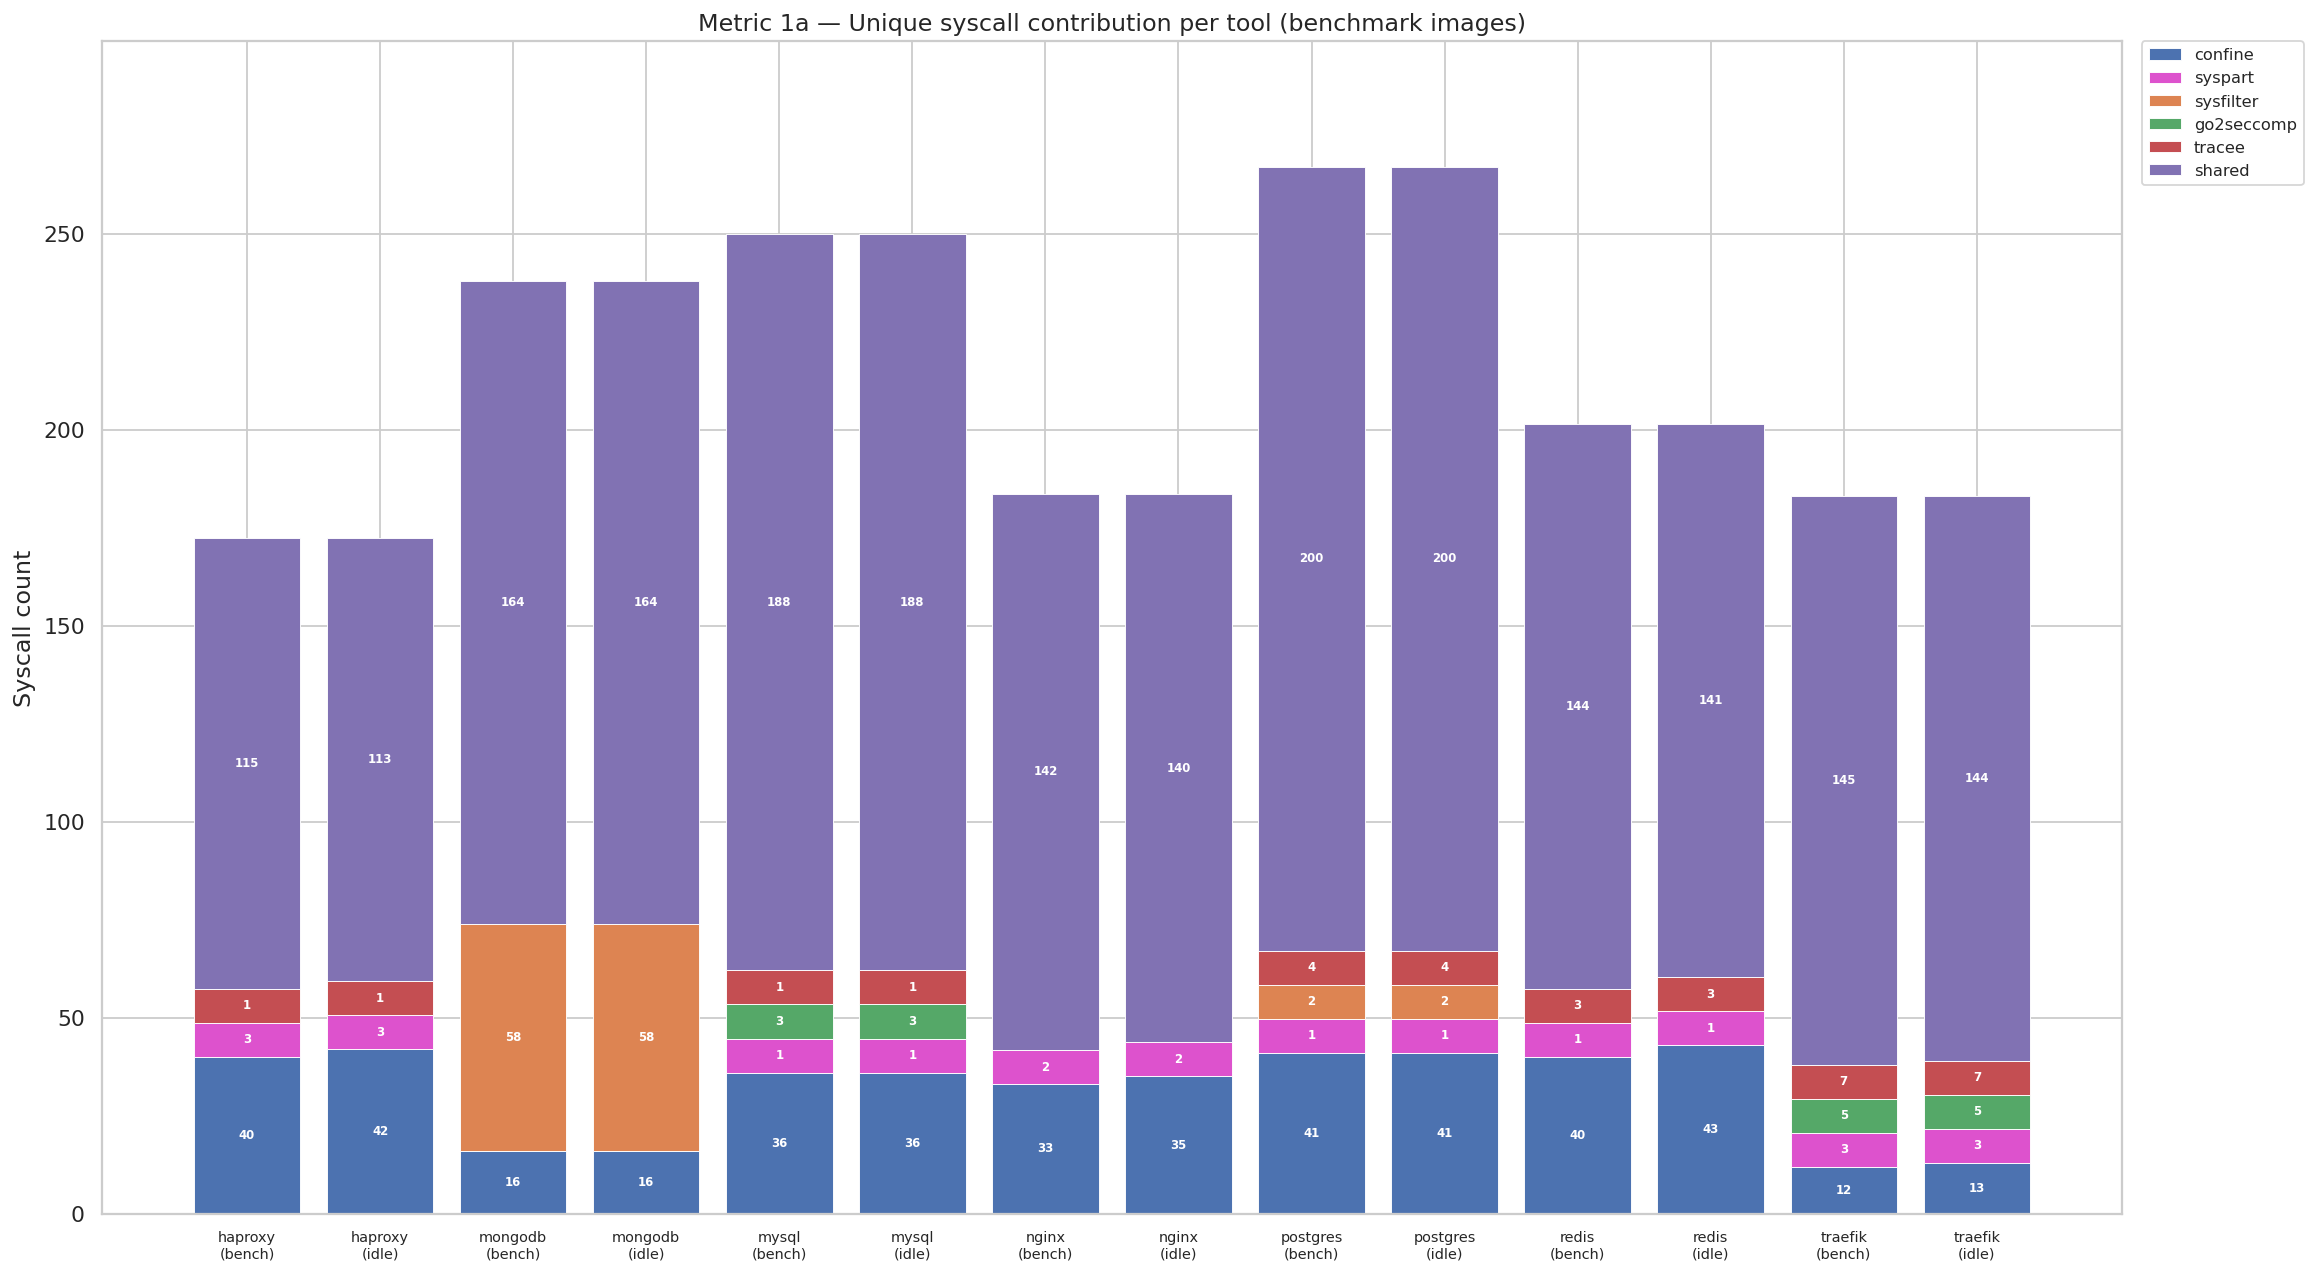

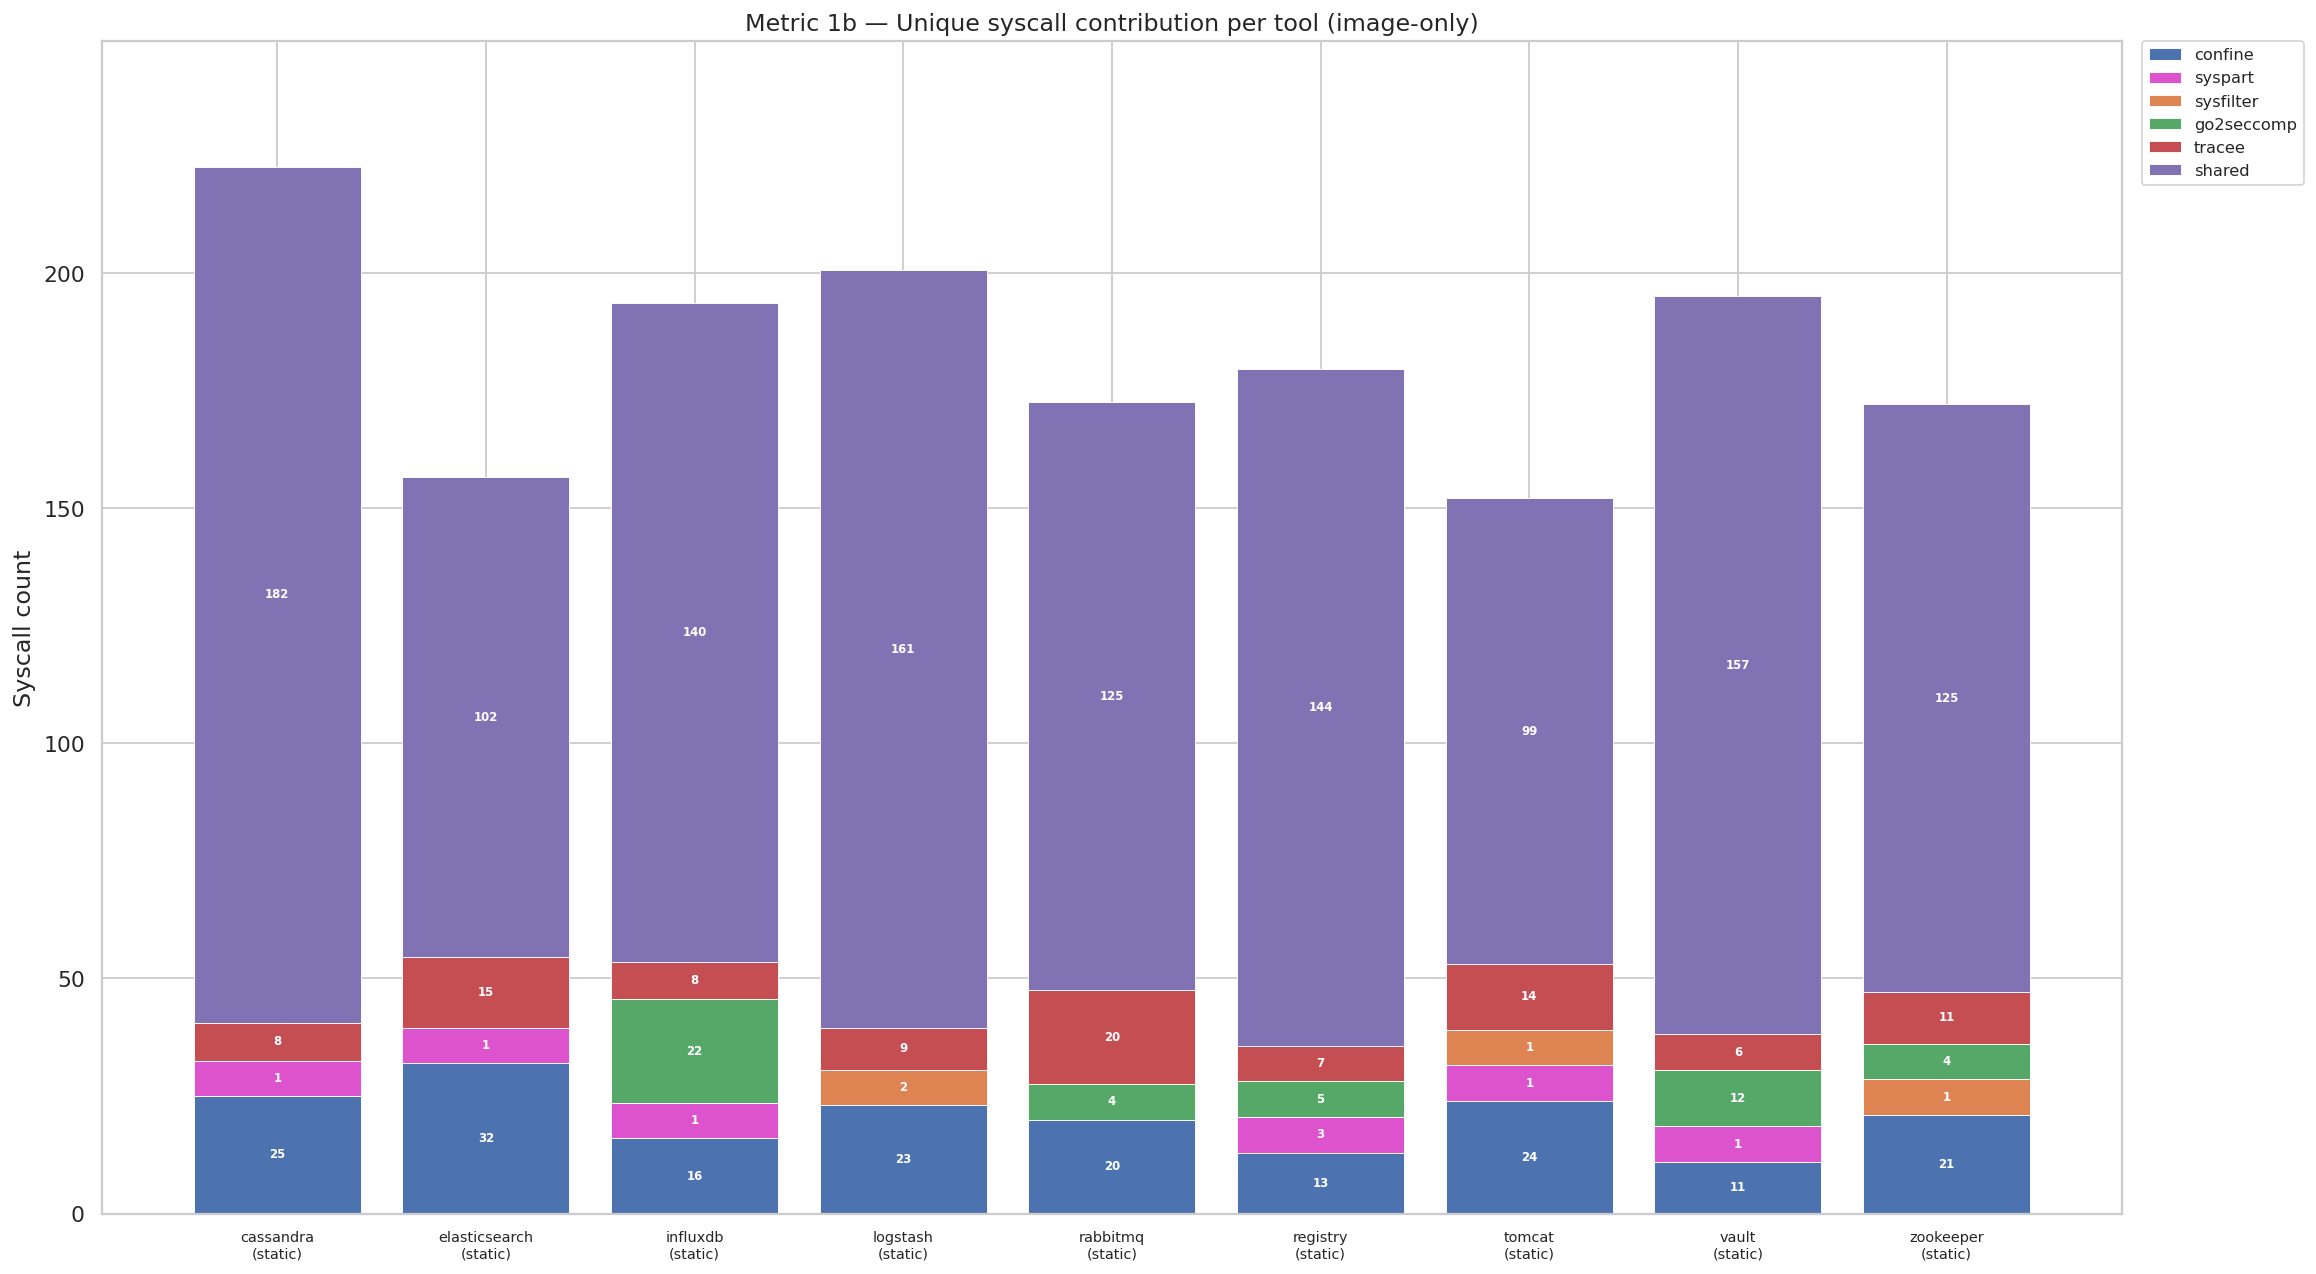

In [113]:
def tool_contribution(per_tool):
    tools = list(per_tool.keys())
    union = set().union(*per_tool.values())
    unique = {t: set() for t in tools}
    shared_set = set()
    for sc in union:
        owners = [t for t in tools if sc in per_tool[t]]
        if len(owners) == 1:
            unique[owners[0]].add(sc)
        else:
            shared_set.add(sc)
    result = {t: len(unique[t]) for t in tools}
    result['shared'] = len(shared_set)
    return result


def plot_tool_contribution(records, title, save_name, figsize=(18, 10)):
    rows = [{'label': f"{r['image']}\n({r['mode']})", **tool_contribution(r['per_tool'])}
            for r in records]
    df = pd.DataFrame(rows).set_index('label').fillna(0).astype(int)
    cols = [c for c in TOOL_ORDER + ['shared'] if c in df.columns]
    df = df[cols]

    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(df))
    totals = df.sum(axis=1).values
    min_h = totals.max() * 0.035

    bottoms = np.zeros(len(df))
    for col in cols:
        vals = df[col].values
        render_h = np.where(vals > 0, np.maximum(vals.astype(float), min_h), 0.0)
        bars = ax.bar(x, render_h, bottom=bottoms,
                      color=TOOL_COLORS.get(col, 'grey'),
                      label=col, edgecolor='white', linewidth=0.5)
        for bar, val, rh, bot in zip(bars, vals, render_h, bottoms):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bot + rh / 2, str(val),
                        ha='center', va='center',
                        fontsize=6.5, color='white', fontweight='bold')
        bottoms += render_h

    ax.set_xticks(x)
    ax.set_xticklabels(df.index, fontsize=8)
    ax.set_ylabel('Syscall count')
    ax.set_title(title)
    rendered_totals = bottoms
    ax.set_ylim(0, rendered_totals.max() * 1.12)
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0, fontsize=9)
    plt.tight_layout()
    save_plot(save_name)
    save_data(df, save_name)
    plt.show()


plot_tool_contribution(
    bench_records,
    'Metric 1a — Unique syscall contribution per tool (benchmark images)',
    'metric_1a'
)
plot_tool_contribution(
    imgonly_records,
    'Metric 1b — Unique syscall contribution per tool (image-only)',
    'metric_1b',
    figsize=(18, 10)
)

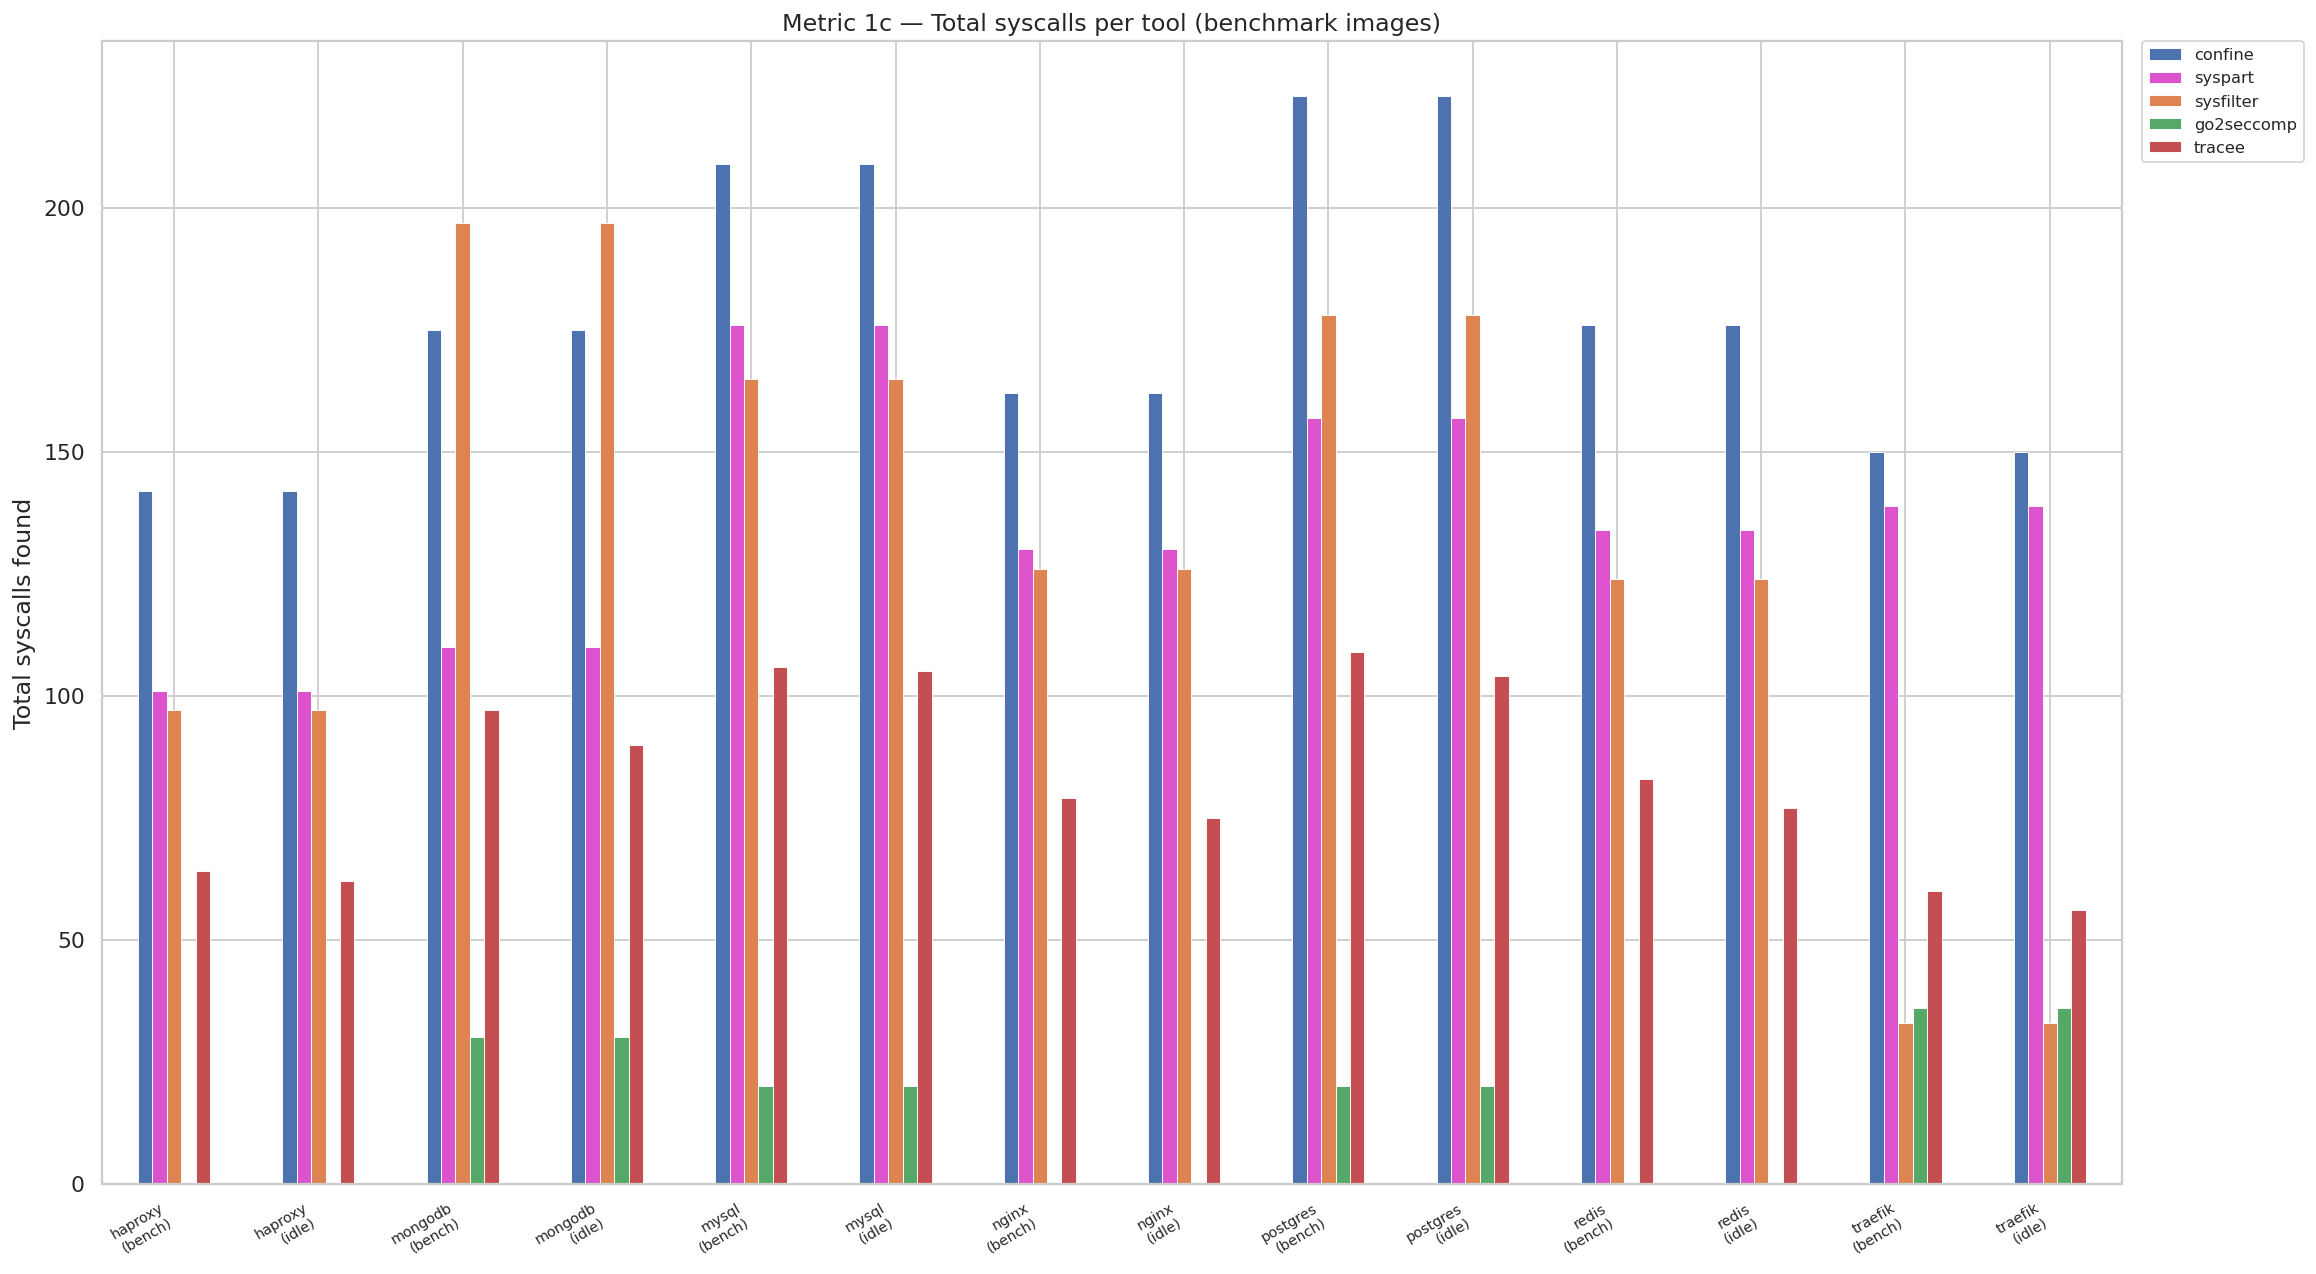

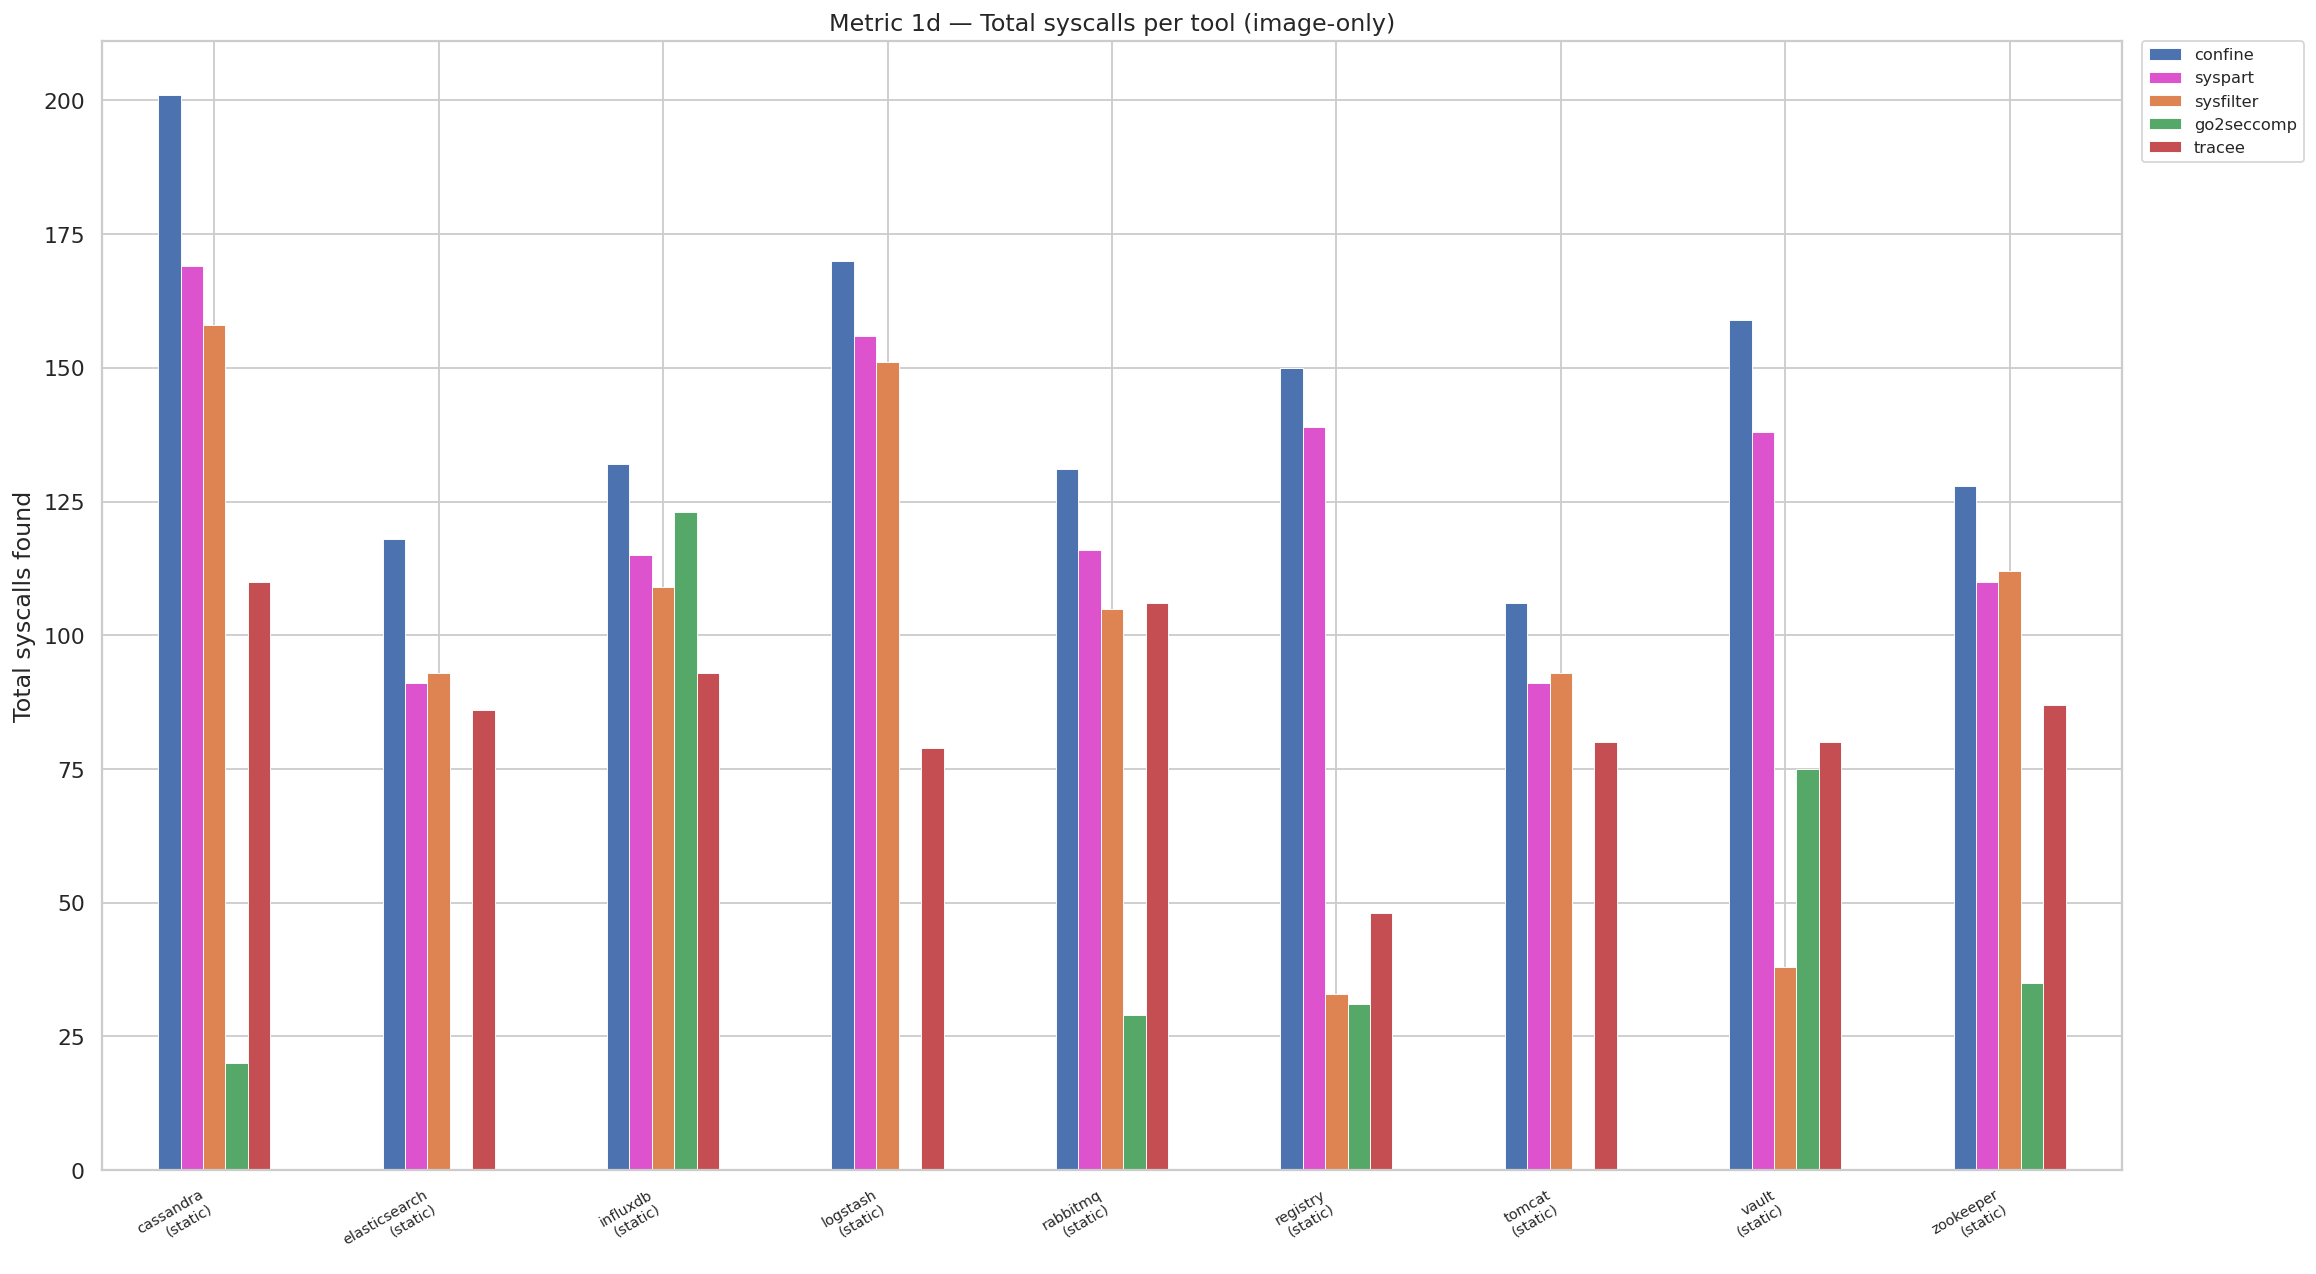

In [114]:
def plot_tool_totals(records, title, save_name, figsize=(18, 10)):
    rows = []
    for rec in records:
        row = {'label': f"{rec['image']}\n({rec['mode']})"}
        for t in TOOL_ORDER:
            row[t] = len(rec['per_tool'].get(t, set()))
        rows.append(row)
    df = pd.DataFrame(rows).set_index('label')
    cols = [c for c in TOOL_ORDER if c in df.columns]
    ax = df[cols].plot(kind='bar', figsize=figsize,
                       color=[TOOL_COLORS[c] for c in cols],
                       edgecolor='white', linewidth=0.5)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('Total syscalls found')
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0, fontsize=9)
    plt.xticks(rotation=30, ha='right', fontsize=8)
    plt.tight_layout()
    save_plot(save_name)
    save_data(df[cols], save_name)
    plt.show()


plot_tool_totals(bench_records,   'Metric 1c — Total syscalls per tool (benchmark images)', 'metric_1c')
plot_tool_totals(imgonly_records, 'Metric 1d — Total syscalls per tool (image-only)',        'metric_1d', figsize=(18, 10))

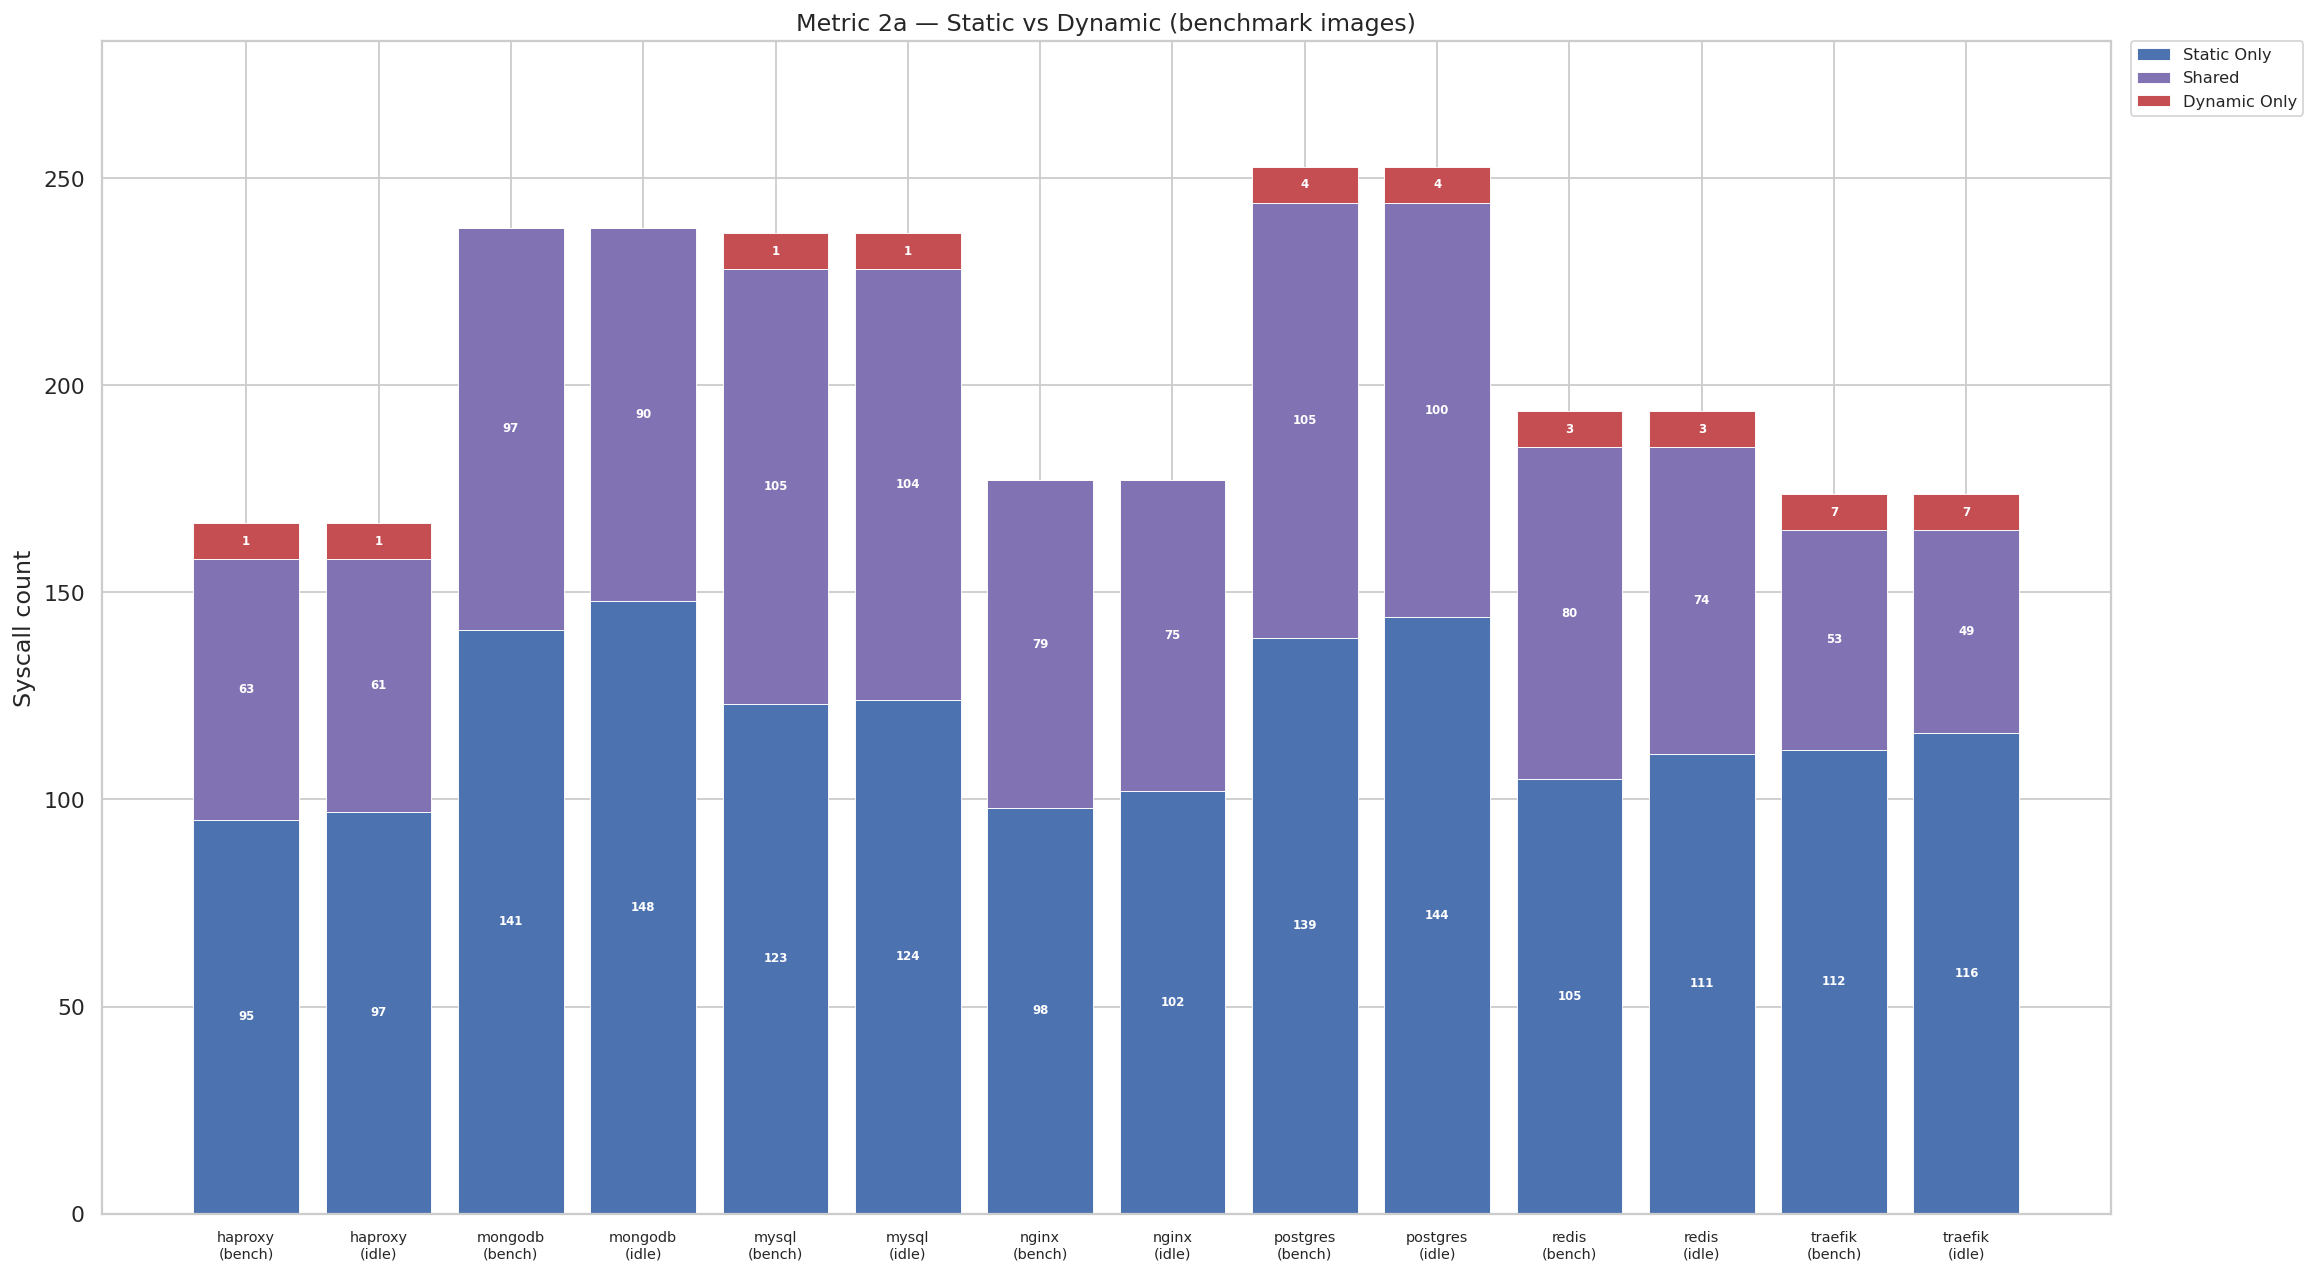

,Static total,Dynamic total,Static only,Dynamic only,Shared
label,,,,,
haproxy\n(bench),158,64,95,1,63
haproxy\n(idle),158,62,97,1,61
mongodb\n(bench),238,97,141,0,97
mongodb\n(idle),238,90,148,0,90
mysql\n(bench),228,106,123,1,105
mysql\n(idle),228,105,124,1,104
nginx\n(bench),177,79,98,0,79
nginx\n(idle),177,75,102,0,75
postgres\n(bench),244,109,139,4,105


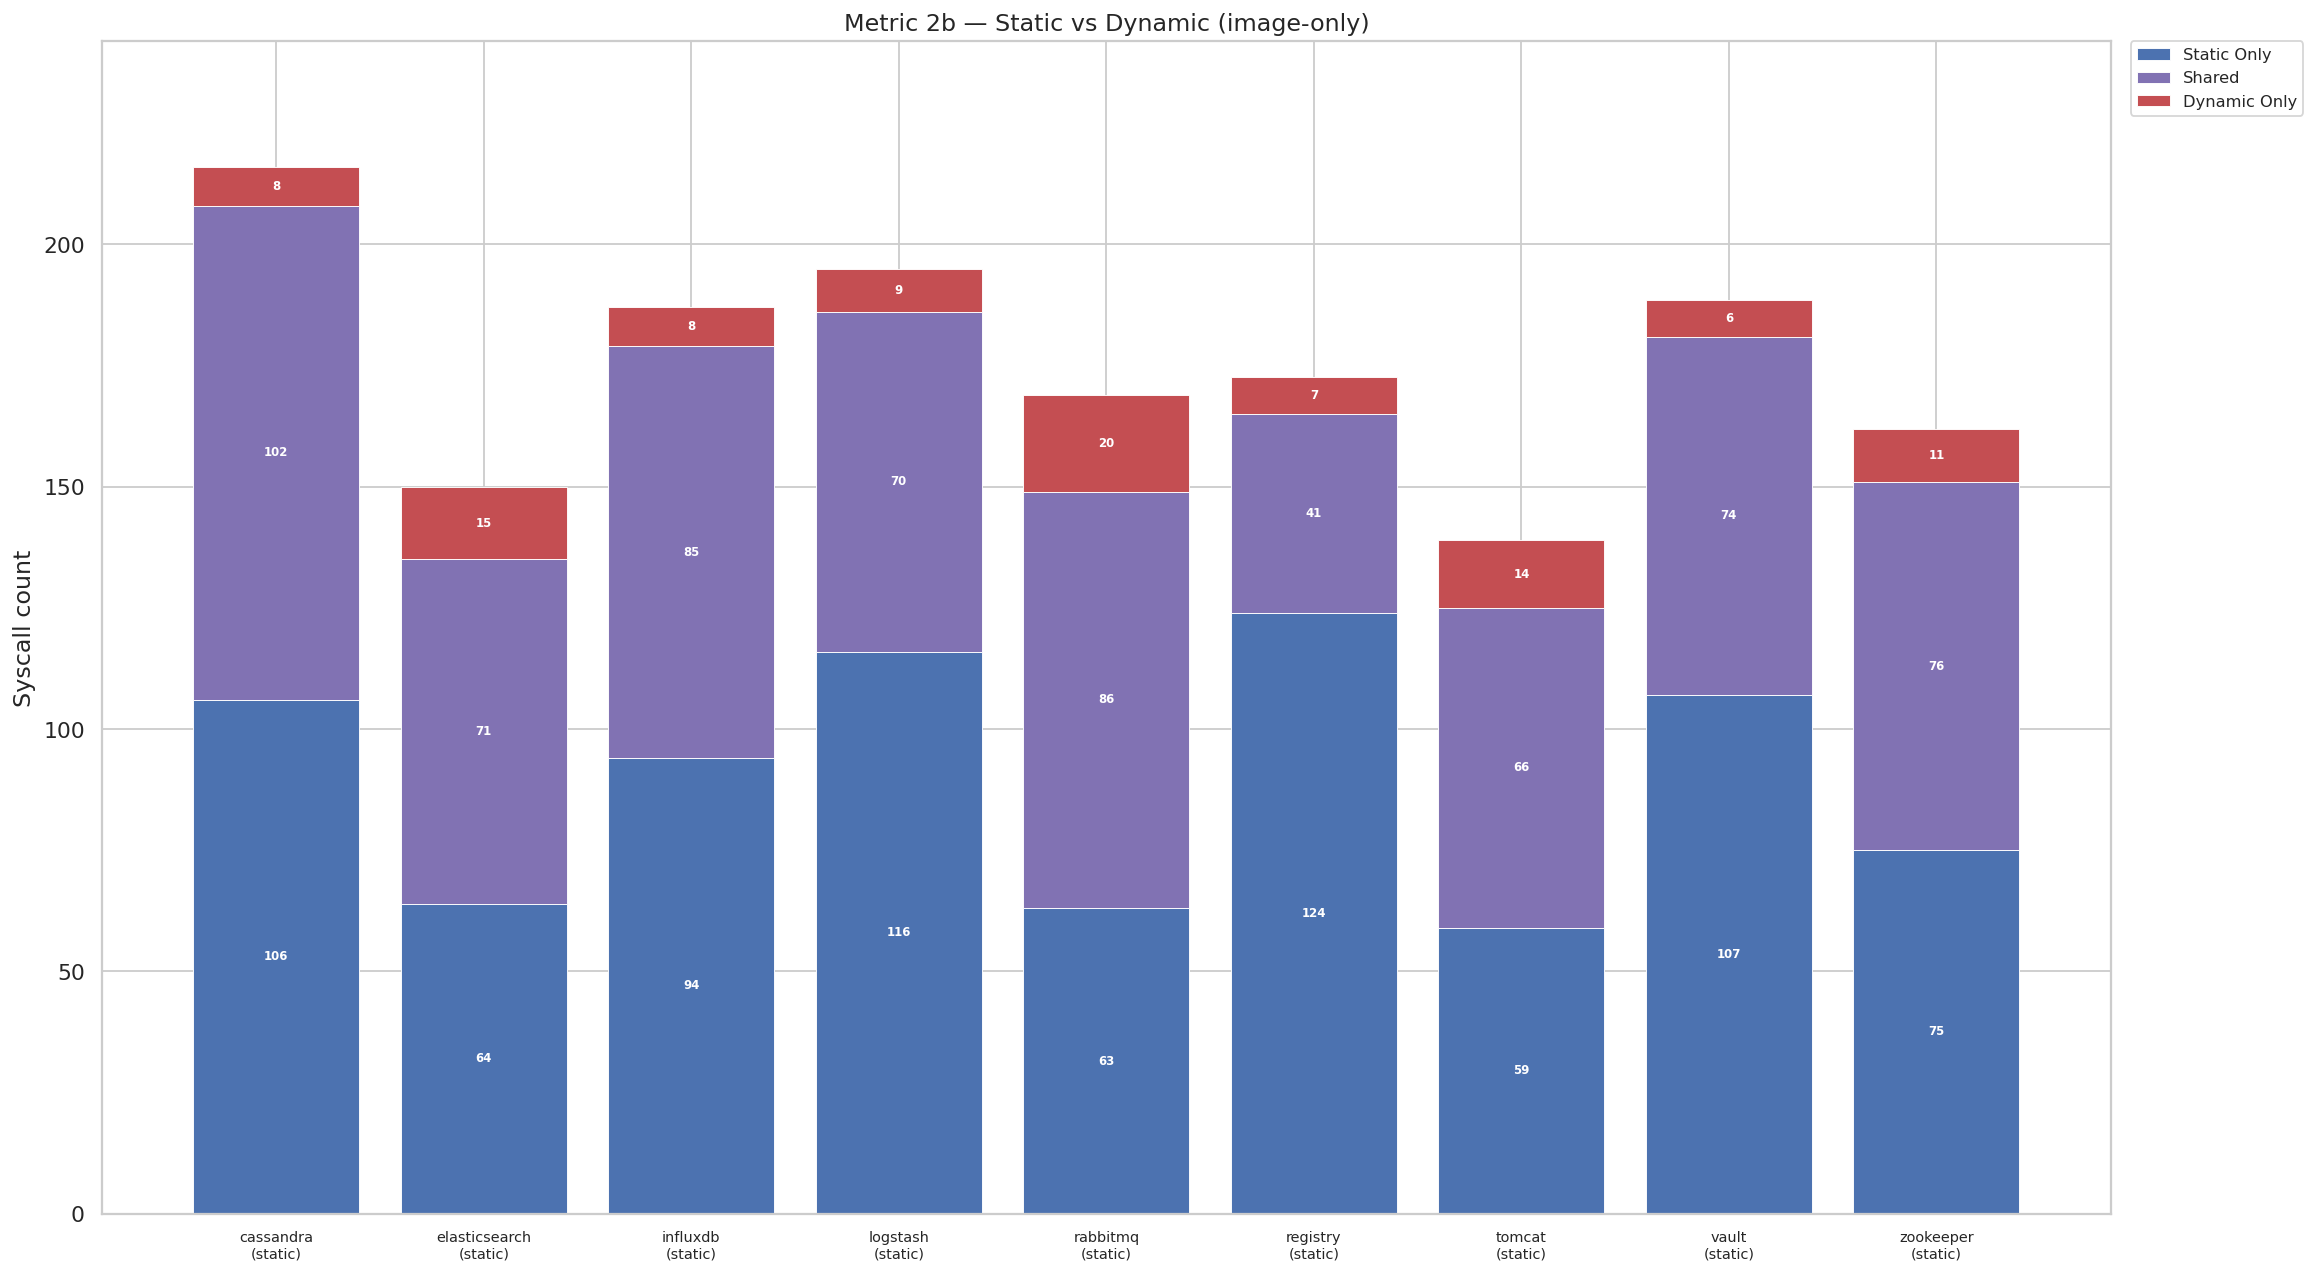

,Static total,Dynamic total,Static only,Dynamic only,Shared
label,,,,,
cassandra\n(static),208,110,106,8,102
elasticsearch\n(static),135,86,64,15,71
influxdb\n(static),179,93,94,8,85
logstash\n(static),186,79,116,9,70
rabbitmq\n(static),149,106,63,20,86
registry\n(static),165,48,124,7,41
tomcat\n(static),125,80,59,14,66
vault\n(static),181,80,107,6,74
zookeeper\n(static),151,87,75,11,76


In [115]:
def static_dynamic_breakdown(rec):
    static  = set().union(*(rec['per_tool'].get(t, set())
                            for t in ['confine', 'syspart','sysfilter', 'go2seccomp']))
    dynamic = rec['per_tool'].get('tracee', set())
    return {
        'static_only':   len(static - dynamic),
        'shared':        len(static & dynamic),
        'dynamic_only':  len(dynamic - static),
        'static_total':  len(static),
        'dynamic_total': len(dynamic),
    }


def plot_static_dynamic(records, title, save_name, figsize=(18, 10)):
    rows = [{'label': f"{r['image']}\n({r['mode']})", **static_dynamic_breakdown(r)}
            for r in records]
    df = pd.DataFrame(rows).set_index('label')

    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(df))

    seg_cols = ['static_only', 'shared', 'dynamic_only']
    colors   = ['#4C72B0', '#8172B3', '#C44E52']
    totals   = df[seg_cols].sum(axis=1).values
    min_h    = totals.max() * 0.035

    bottoms = np.zeros(len(df))
    for col, color in zip(seg_cols, colors):
        vals    = df[col].values
        render_h = np.where(vals > 0, np.maximum(vals.astype(float), min_h), 0.0)
        bars = ax.bar(x, render_h, bottom=bottoms, color=color,
                      label=col.replace('_', ' ').title(),
                      edgecolor='white', linewidth=0.5)
        for bar, val, rh, bot in zip(bars, vals, render_h, bottoms):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bot + rh / 2,
                        str(val),
                        ha='center', va='center',
                        fontsize=6.5, color='white', fontweight='bold')
        bottoms += render_h

    ax.set_xticks(x)
    ax.set_xticklabels(df.index, fontsize=8)
    rendered_totals = bottoms
    ax.set_ylim(0, rendered_totals.max() * 1.12)
    ax.set_ylabel('Syscall count')
    ax.set_title(title)
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0, fontsize=9)
    plt.tight_layout()
    save_plot(save_name)
    save_data(df[seg_cols + ['static_total', 'dynamic_total']], save_name)
    plt.show()

    summary = df[['static_total','dynamic_total','static_only','dynamic_only','shared']].copy()
    summary.columns = ['Static total','Dynamic total','Static only','Dynamic only','Shared']
    display(summary)


plot_static_dynamic(bench_records,   'Metric 2a — Static vs Dynamic (benchmark images)', 'metric_2a')
plot_static_dynamic(imgonly_records, 'Metric 2b — Static vs Dynamic (image-only)',        'metric_2b', figsize=(18, 10))

In [116]:
def tool_union(rec):
    result = set()
    for s in rec['per_tool'].values():
        result |= s
    return result

idle_found  = {r['image']: tool_union(r) for r in bench_records if r['mode'] == 'idle'}
bench_found = {r['image']: tool_union(r) for r in bench_records if r['mode'] == 'bench'}

common_images = sorted(set(idle_found) & set(bench_found))
print('Images with both idle and bench result files:', common_images)

rows = []
for img in common_images:
    I, B = idle_found[img], bench_found[img]
    rows.append({
        'image':            img,
        'idle':             len(I),
        'bench':            len(B),
        'shared':           len(I & B),
        'bench_only':       len(B - I),
        'idle_only':        len(I - B),
        'bench_only_names': sorted(B - I),
        'idle_only_names':  sorted(I - B),
    })

df_ib = pd.DataFrame(rows).set_index('image')
display(df_ib[['idle', 'bench', 'shared', 'bench_only', 'idle_only']])

Images with both idle and bench result files: ['haproxy', 'mongodb', 'mysql', 'nginx', 'postgres', 'redis', 'traefik']


,idle,bench,shared,bench_only,idle_only
image,,,,,
haproxy,159,159,159,0,0
mongodb,238,238,238,0,0
mysql,229,229,229,0,0
nginx,177,177,177,0,0
postgres,248,248,248,0,0
redis,188,188,188,0,0
traefik,172,172,172,0,0


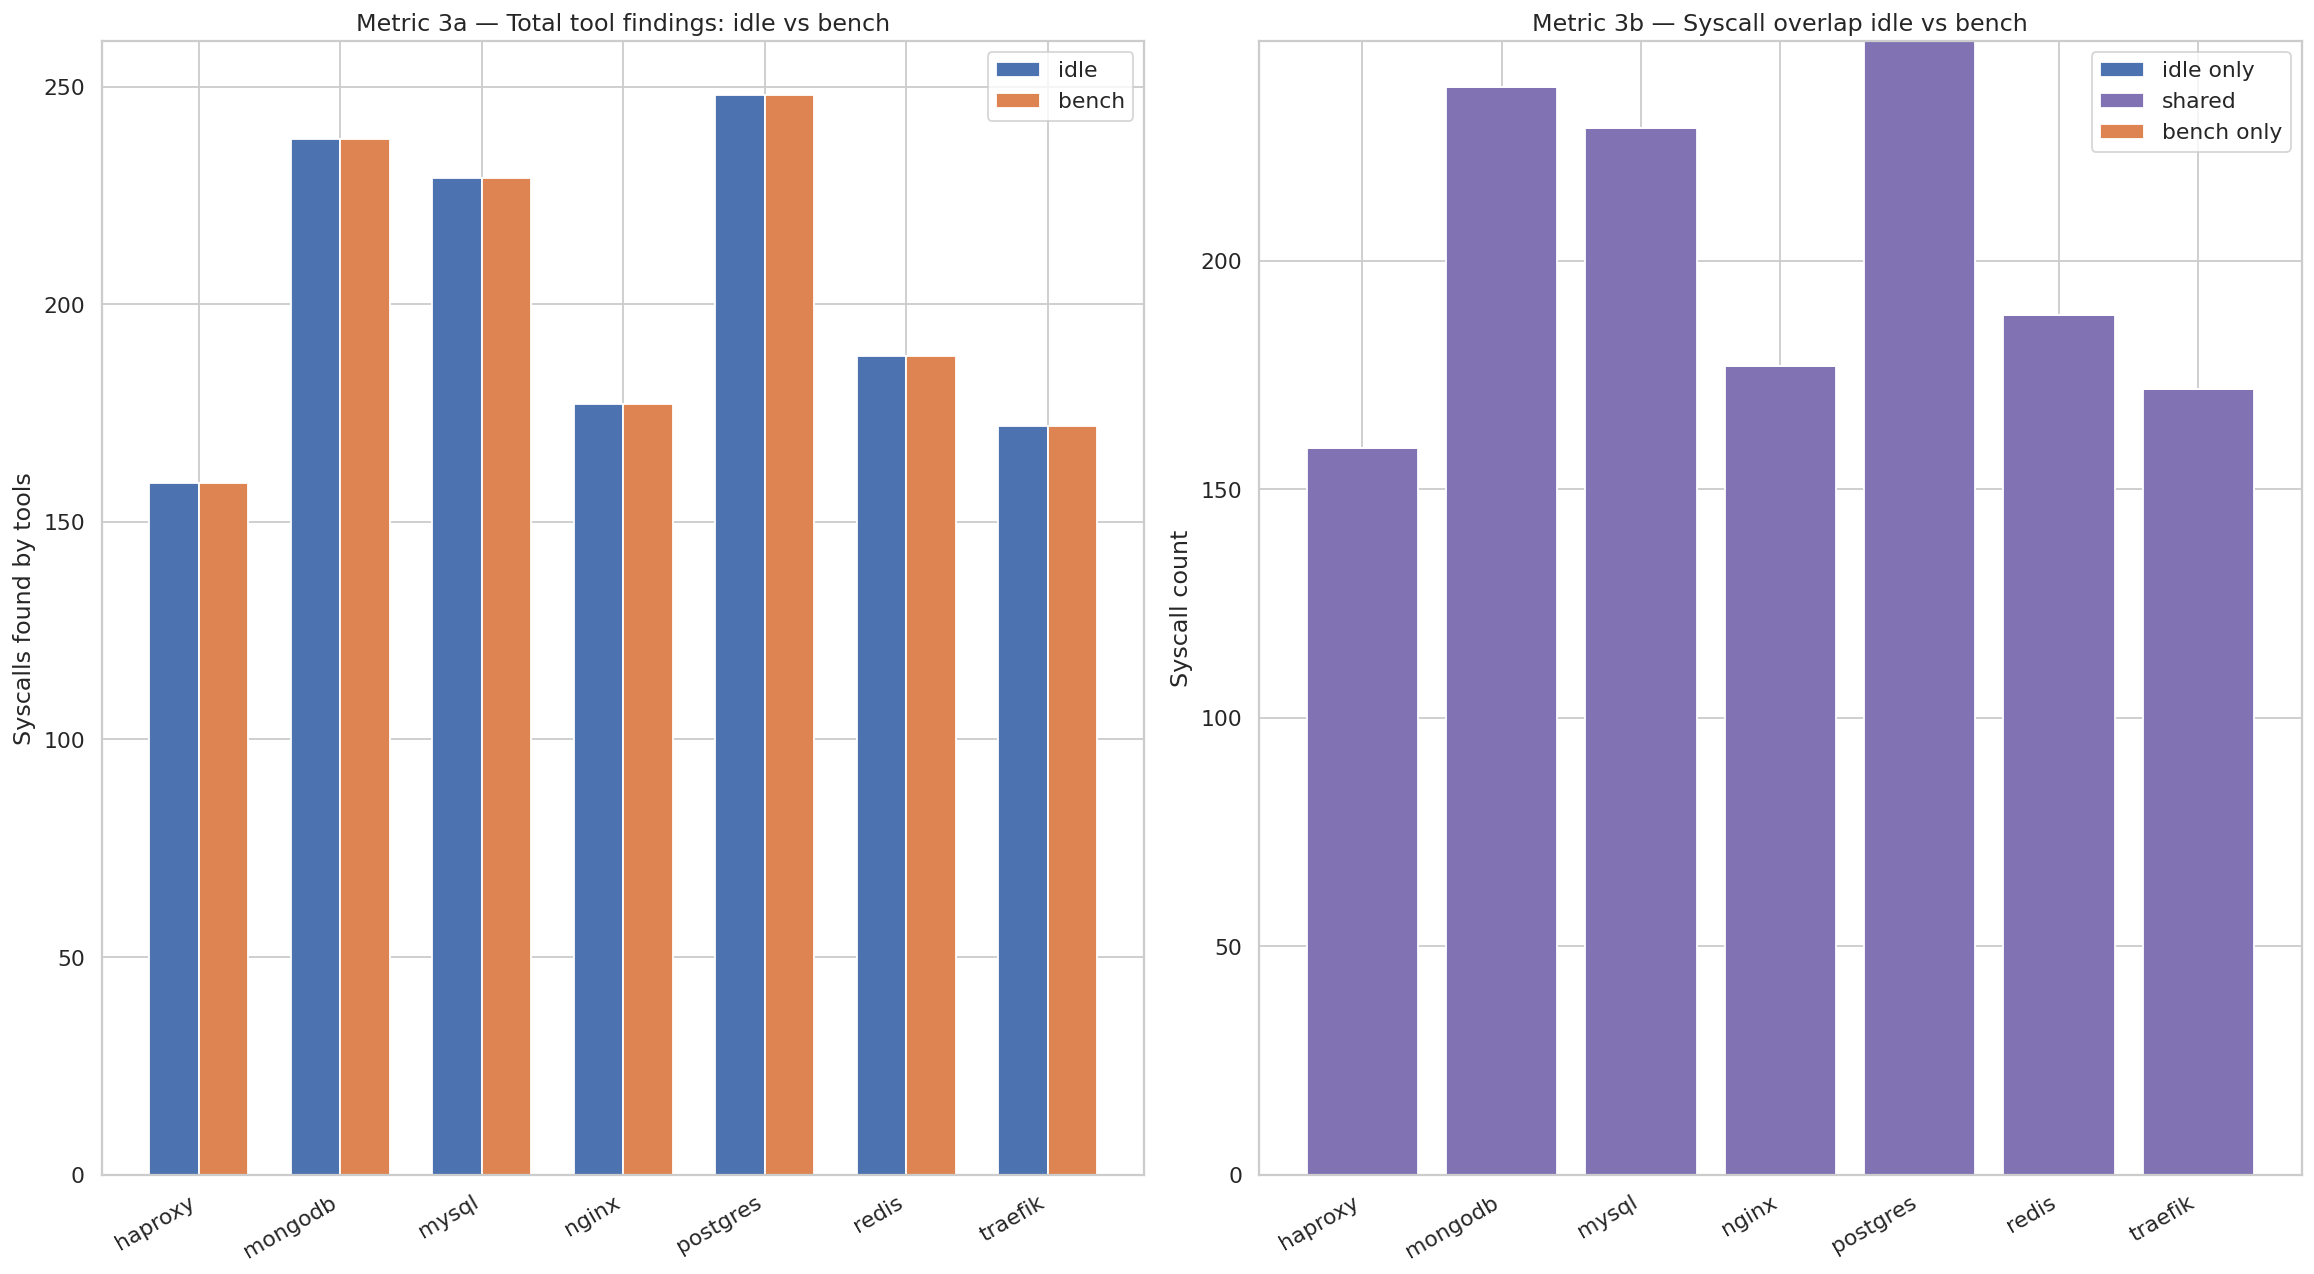

In [117]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
x = np.arange(len(common_images))
w = 0.35

# Left: total idle vs bench
ax = axes[0]
ax.bar(x - w/2, df_ib['idle'],  w, label='idle',  color='#4C72B0')
ax.bar(x + w/2, df_ib['bench'], w, label='bench', color='#DD8452')
ax.set_xticks(x)
ax.set_xticklabels(common_images, rotation=30, ha='right')
ax.set_ylabel('Syscalls found by tools')
ax.set_title('Metric 3a — Total tool findings: idle vs bench')
ax.legend()

# Right: stacked overlap
ax = axes[1]
io = df_ib['idle_only'].values
sh = df_ib['shared'].values
bo = df_ib['bench_only'].values
ax.bar(x, io, color='#4C72B0', label='idle only')
ax.bar(x, sh, color='#8172B3', label='shared', bottom=io)
ax.bar(x, bo, color='#DD8452', label='bench only', bottom=io + sh)
for i, (b, s, o) in enumerate(zip(bo, sh, io)):
    if b > 0:
        ax.text(i, o + s + b / 2, str(b),
                ha='center', va='center', fontsize=8, color='white', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(common_images, rotation=30, ha='right')
ax.set_title('Metric 3b — Syscall overlap idle vs bench')
ax.set_ylabel('Syscall count')
ax.legend()

plt.tight_layout()
save_plot('metric_3')
save_data(df_ib[['idle', 'bench', 'shared', 'bench_only', 'idle_only']], 'metric_3')
plt.show()

In [118]:
print('=== Syscalls found ONLY in bench mode (discovered under load) ===')
for _, row in df_ib.iterrows():
    names = row['bench_only_names']
    print(f"\n{row.name} +{len(names)}: {', '.join(names) if names else '—'}")

print('\n=== Syscalls found ONLY in idle mode (absent under load) ===')
for _, row in df_ib.iterrows():
    names = row['idle_only_names']
    print(f"\n{row.name} -{len(names)}: {', '.join(names) if names else '—'}")

=== Syscalls found ONLY in bench mode (discovered under load) ===

haproxy +0: —

mongodb +0: —

mysql +0: —

nginx +0: —

postgres +0: —

redis +0: —

traefik +0: —

=== Syscalls found ONLY in idle mode (absent under load) ===

haproxy -0: —

mongodb -0: —

mysql -0: —

nginx -0: —

postgres -0: —

redis -0: —

traefik -0: —


In [119]:
def mitigated_cves(allowed):
    return {cve for cve, req in cve2syscalls.items() if not req & allowed}

METRICS_4_6_MODES = {'static', 'idle'}
metrics_profiles = {
    (image, mode): allowed
    for (image, mode), allowed in merged.items()
    if mode in METRICS_4_6_MODES
}

docker_mitigated = mitigated_cves(docker_allowed)
print(f'Docker default mitigates: {len(docker_mitigated)} / {len(cve2syscalls)} CVEs')

cve_rows = []
for (image, mode), allowed in sorted(metrics_profiles.items()):
    m = mitigated_cves(allowed)
    cve_rows.append({
        'image': image,
        'mitigated':      len(m),
        'extra_vs_docker': len(m - docker_mitigated),
        'docker_only':     len(docker_mitigated - m),
    })
df_cve = pd.DataFrame(cve_rows)
display(df_cve.sort_values(['image']))


Docker default mitigates: 22 / 107 CVEs


,image,mitigated,extra_vs_docker,docker_only
0,cassandra,15,12,19
1,elasticsearch,47,25,0
2,haproxy,43,21,0
3,influxdb,34,15,3
4,logstash,40,21,3
5,mongodb,21,15,16
6,mysql,33,14,3
7,nginx,37,18,3
8,postgres,19,14,17
9,rabbitmq,41,22,3


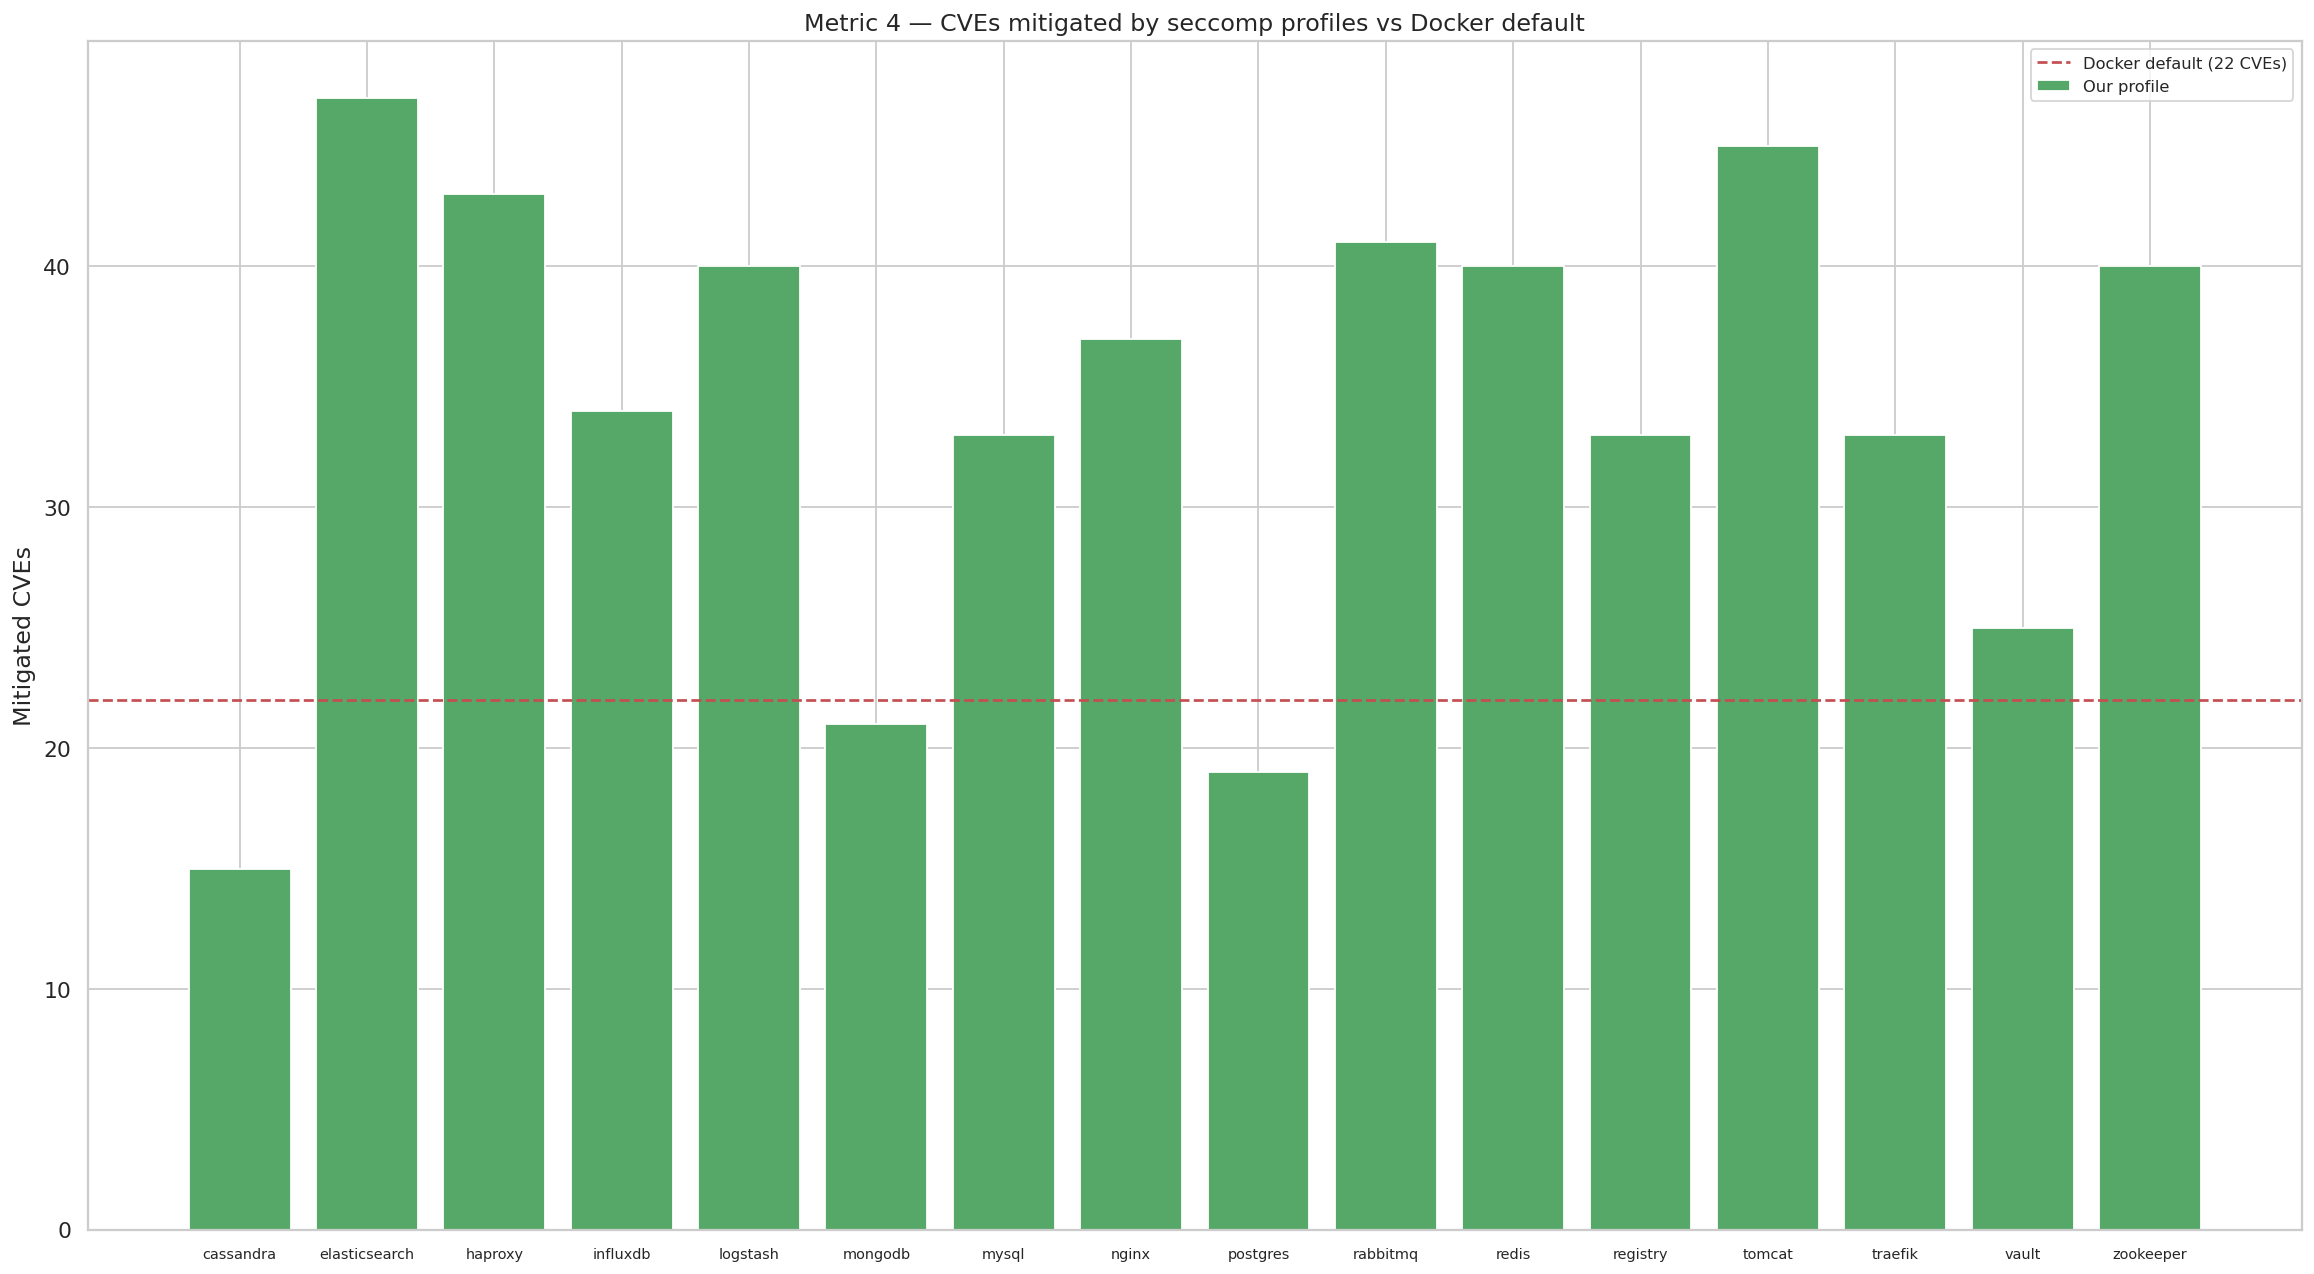

Total CVEs in mapping  : 107
Docker default mitigates: 22
Best of our profiles   : elasticsearch — 47 CVEs


In [ ]:
df_plot = df_cve.copy()
df_plot['label'] = df_plot['image']
df_plot = df_plot.sort_values('label').reset_index(drop=True)
x = np.arange(len(df_plot))

fig, ax = plt.subplots(figsize=(18, 10))
ax.bar(x, df_plot['mitigated'], color='#55A868', label='Constant-in profile')
ax.axhline(len(docker_mitigated), color='#C44E52', linestyle='--', linewidth=1.5,
           label=f'Docker default ({len(docker_mitigated)} CVEs)')
ax.set_xticks(x)
ax.set_xticklabels(df_plot['label'], fontsize=8)
ax.set_ylabel('Mitigated CVEs')
ax.set_title('Metric 4 — CVEs mitigated by seccomp profiles vs Docker default')
ax.legend(fontsize=9)
plt.tight_layout()
save_plot('metric_4a')
save_data(df_plot[['label', 'mitigated', 'extra_vs_docker', 'docker_only']].set_index('label'), 'metric_4a')
plt.show()

best = df_cve.loc[df_cve['mitigated'].idxmax()]
print(f'Total CVEs in mapping  : {len(cve2syscalls)}')
print(f'Docker default mitigates: {len(docker_mitigated)}')
print(f'Best of our profiles   : {best["image"]} — {best["mitigated"]} CVEs')


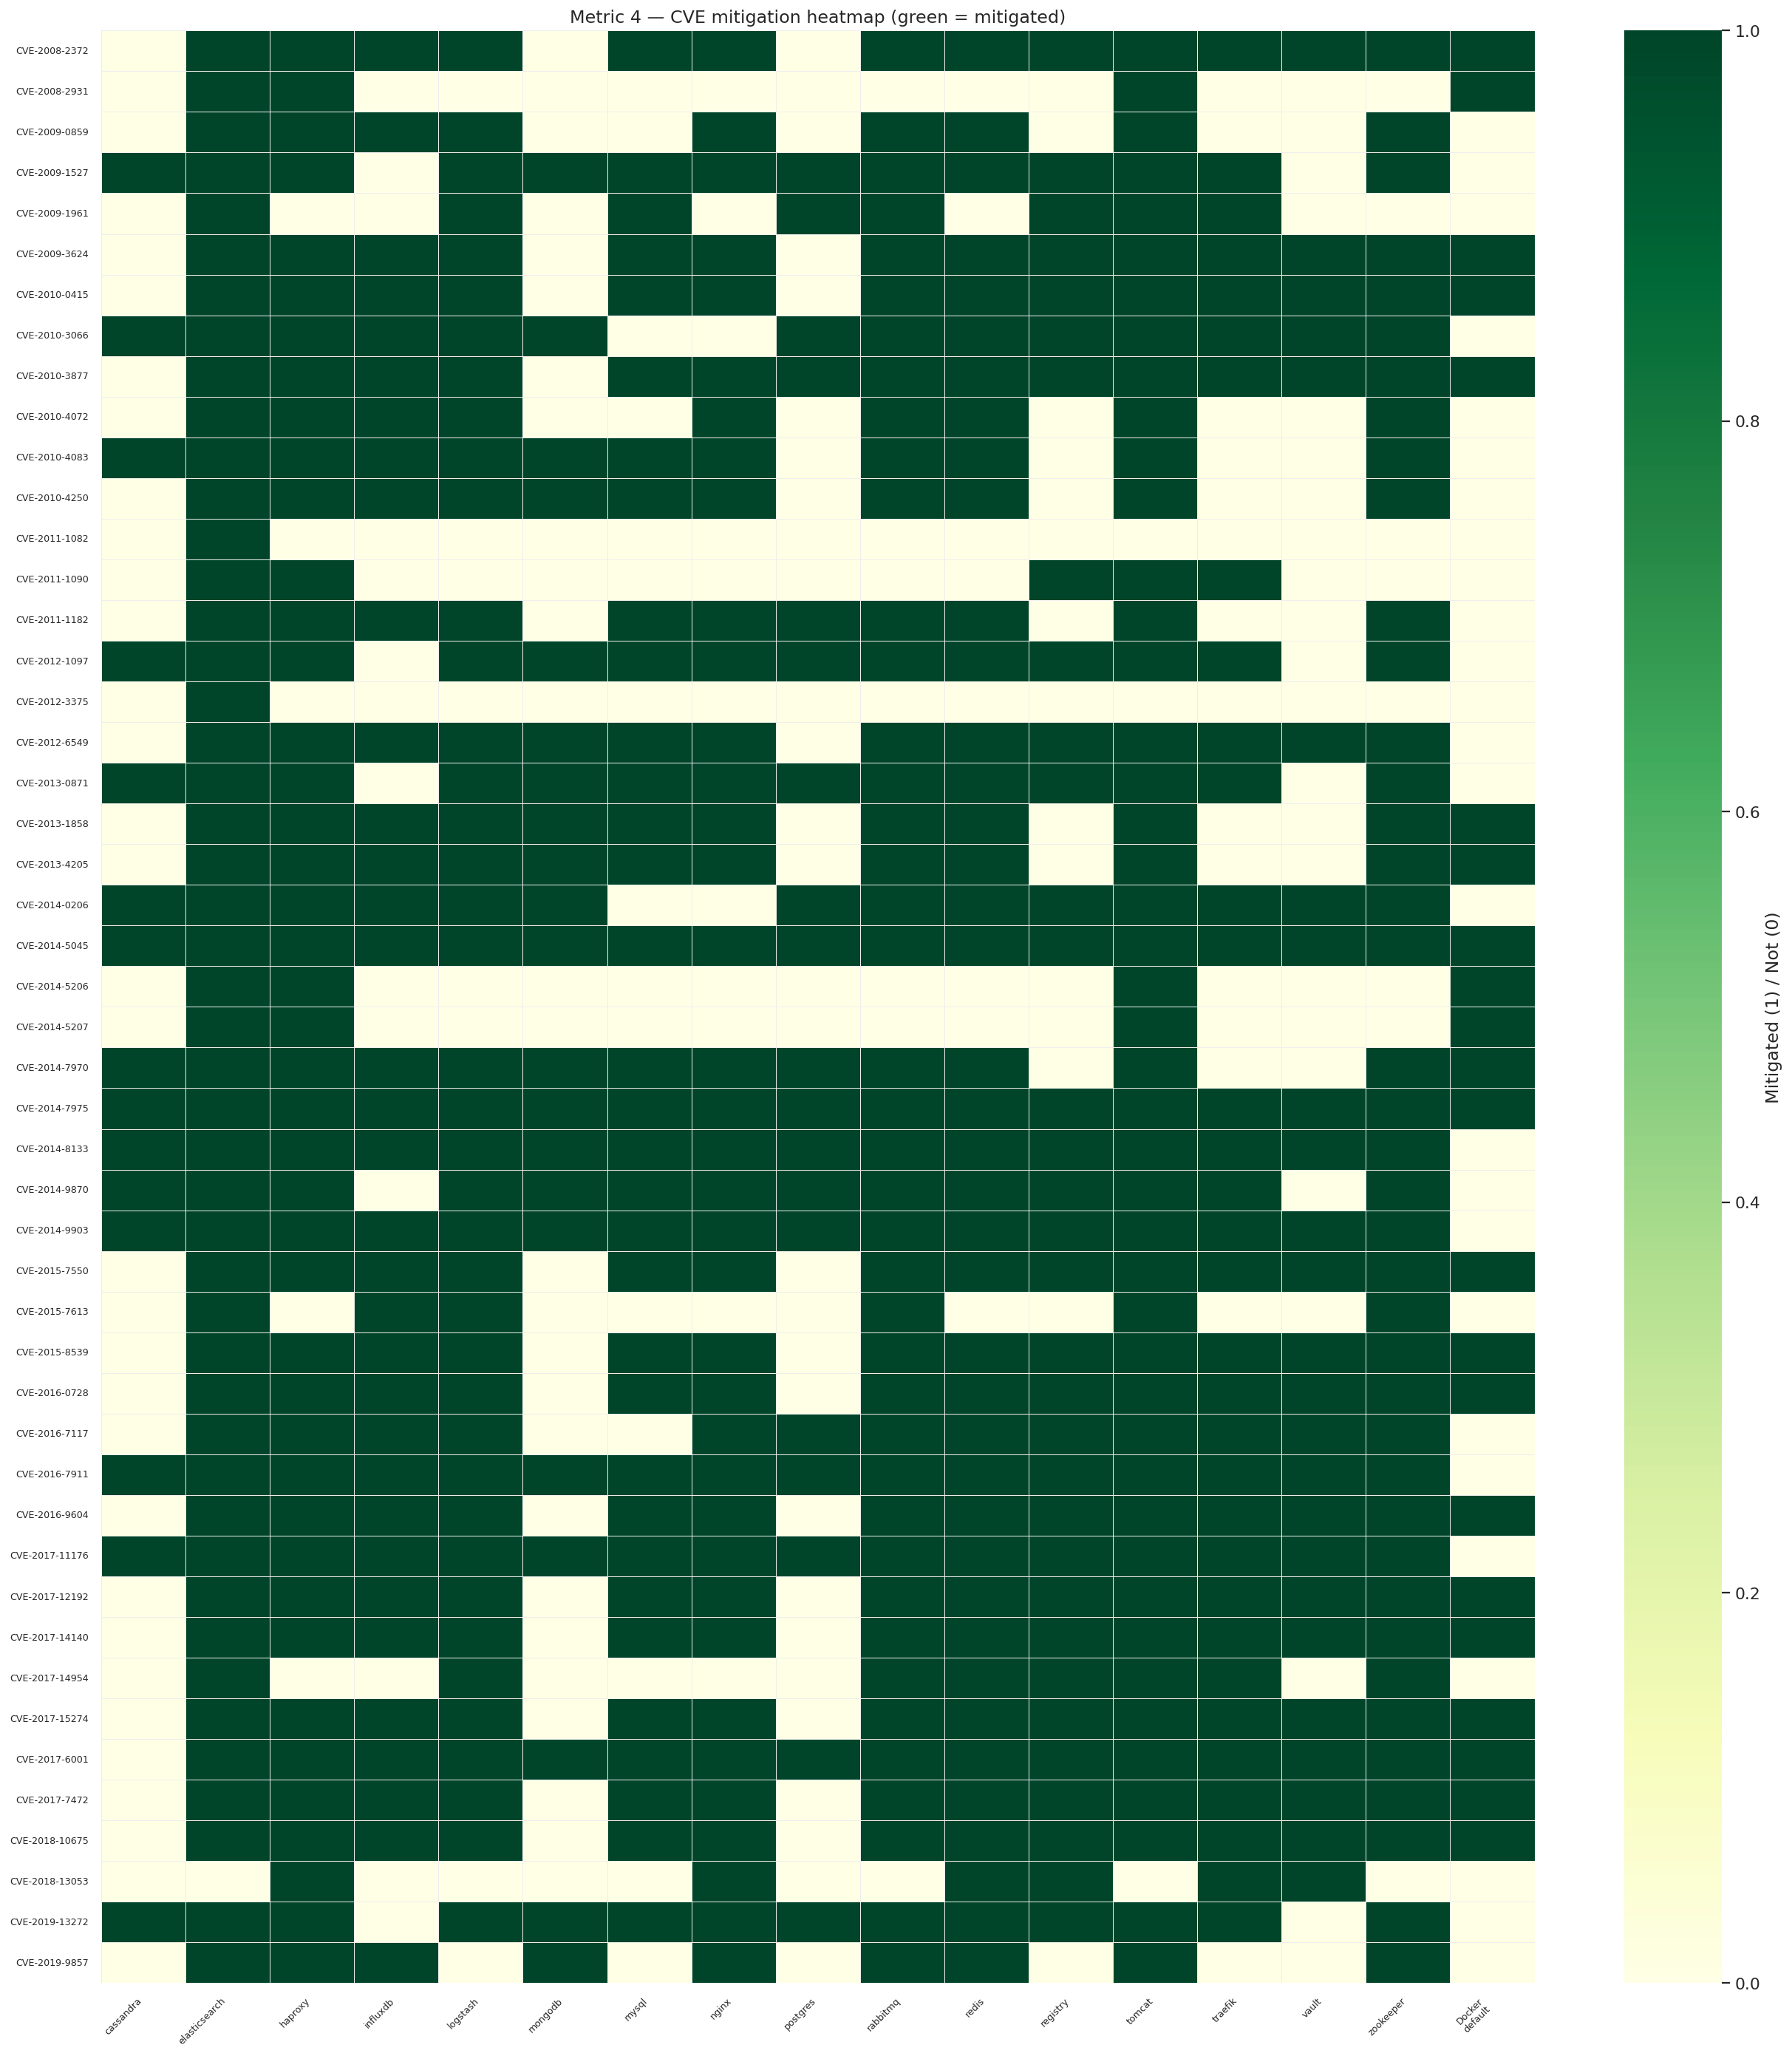

In [121]:
all_cves    = sorted(cve2syscalls.keys())
all_keys    = sorted(metrics_profiles.keys())
col_labels  = [img for img, _ in all_keys] + ['Docker\ndefault']

matrix = np.zeros((len(all_cves), len(all_keys) + 1), dtype=int)
for j, (image, mode) in enumerate(all_keys):
    allowed = metrics_profiles[(image, mode)]
    for i, cve in enumerate(all_cves):
        if not cve2syscalls[cve] & allowed:
            matrix[i, j] = 1
for i, cve in enumerate(all_cves):
    if cve in docker_mitigated:
        matrix[i, -1] = 1

mask   = matrix.sum(axis=1) > 0
mat_f  = matrix[mask]
cve_f  = [c for c, m in zip(all_cves, mask) if m]

fig, ax = plt.subplots(figsize=(max(20, len(col_labels) * 1.0), max(6, len(cve_f) * 0.45)))
sns.heatmap(mat_f, ax=ax,
            xticklabels=col_labels, yticklabels=cve_f,
            cmap='YlGn', linewidths=0.3, linecolor='#eee',
            cbar_kws={'label': 'Mitigated (1) / Not (0)'},
            vmin=0, vmax=1)
ax.set_title('Metric 4 — CVE mitigation heatmap (green = mitigated)')
ax.set_xticklabels(ax.get_xticklabels(), fontsize=7, rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)
plt.tight_layout()
save_plot('metric_4b')
save_data(pd.DataFrame(mat_f, index=cve_f, columns=col_labels), 'metric_4b')
plt.show()


In [122]:
docker_rows = []
for (image, mode), allowed in sorted(metrics_profiles.items()):
    allowed_x86_64 = allowed & ALL_SYSCALLS
    additionally_blocked = docker_allowed - allowed_x86_64
    docker_rows.append({
        'image':   image,
        'our_total':            len(allowed_x86_64),
        'docker_total':         len(docker_allowed),
        'both_allowed':         len(docker_allowed & allowed_x86_64),
        'additionally_blocked': len(additionally_blocked),
        'reduction_pct':        round(100 * len(additionally_blocked) / len(docker_allowed), 1),
    })
df_docker = pd.DataFrame(docker_rows)
display(df_docker.sort_values(['image'])[[
    'image','our_total','docker_total','both_allowed','additionally_blocked','reduction_pct'
]])


,image,our_total,docker_total,both_allowed,additionally_blocked,reduction_pct
0,cassandra,216,304,195,109,35.9
1,elasticsearch,157,304,151,153,50.3
2,haproxy,164,304,157,147,48.4
3,influxdb,188,304,179,125,41.1
4,logstash,199,304,190,114,37.5
5,mongodb,241,304,219,85,28.0
6,mysql,230,304,220,84,27.6
7,nginx,181,304,174,130,42.8
8,postgres,249,304,222,82,27.0
9,rabbitmq,172,304,163,141,46.4


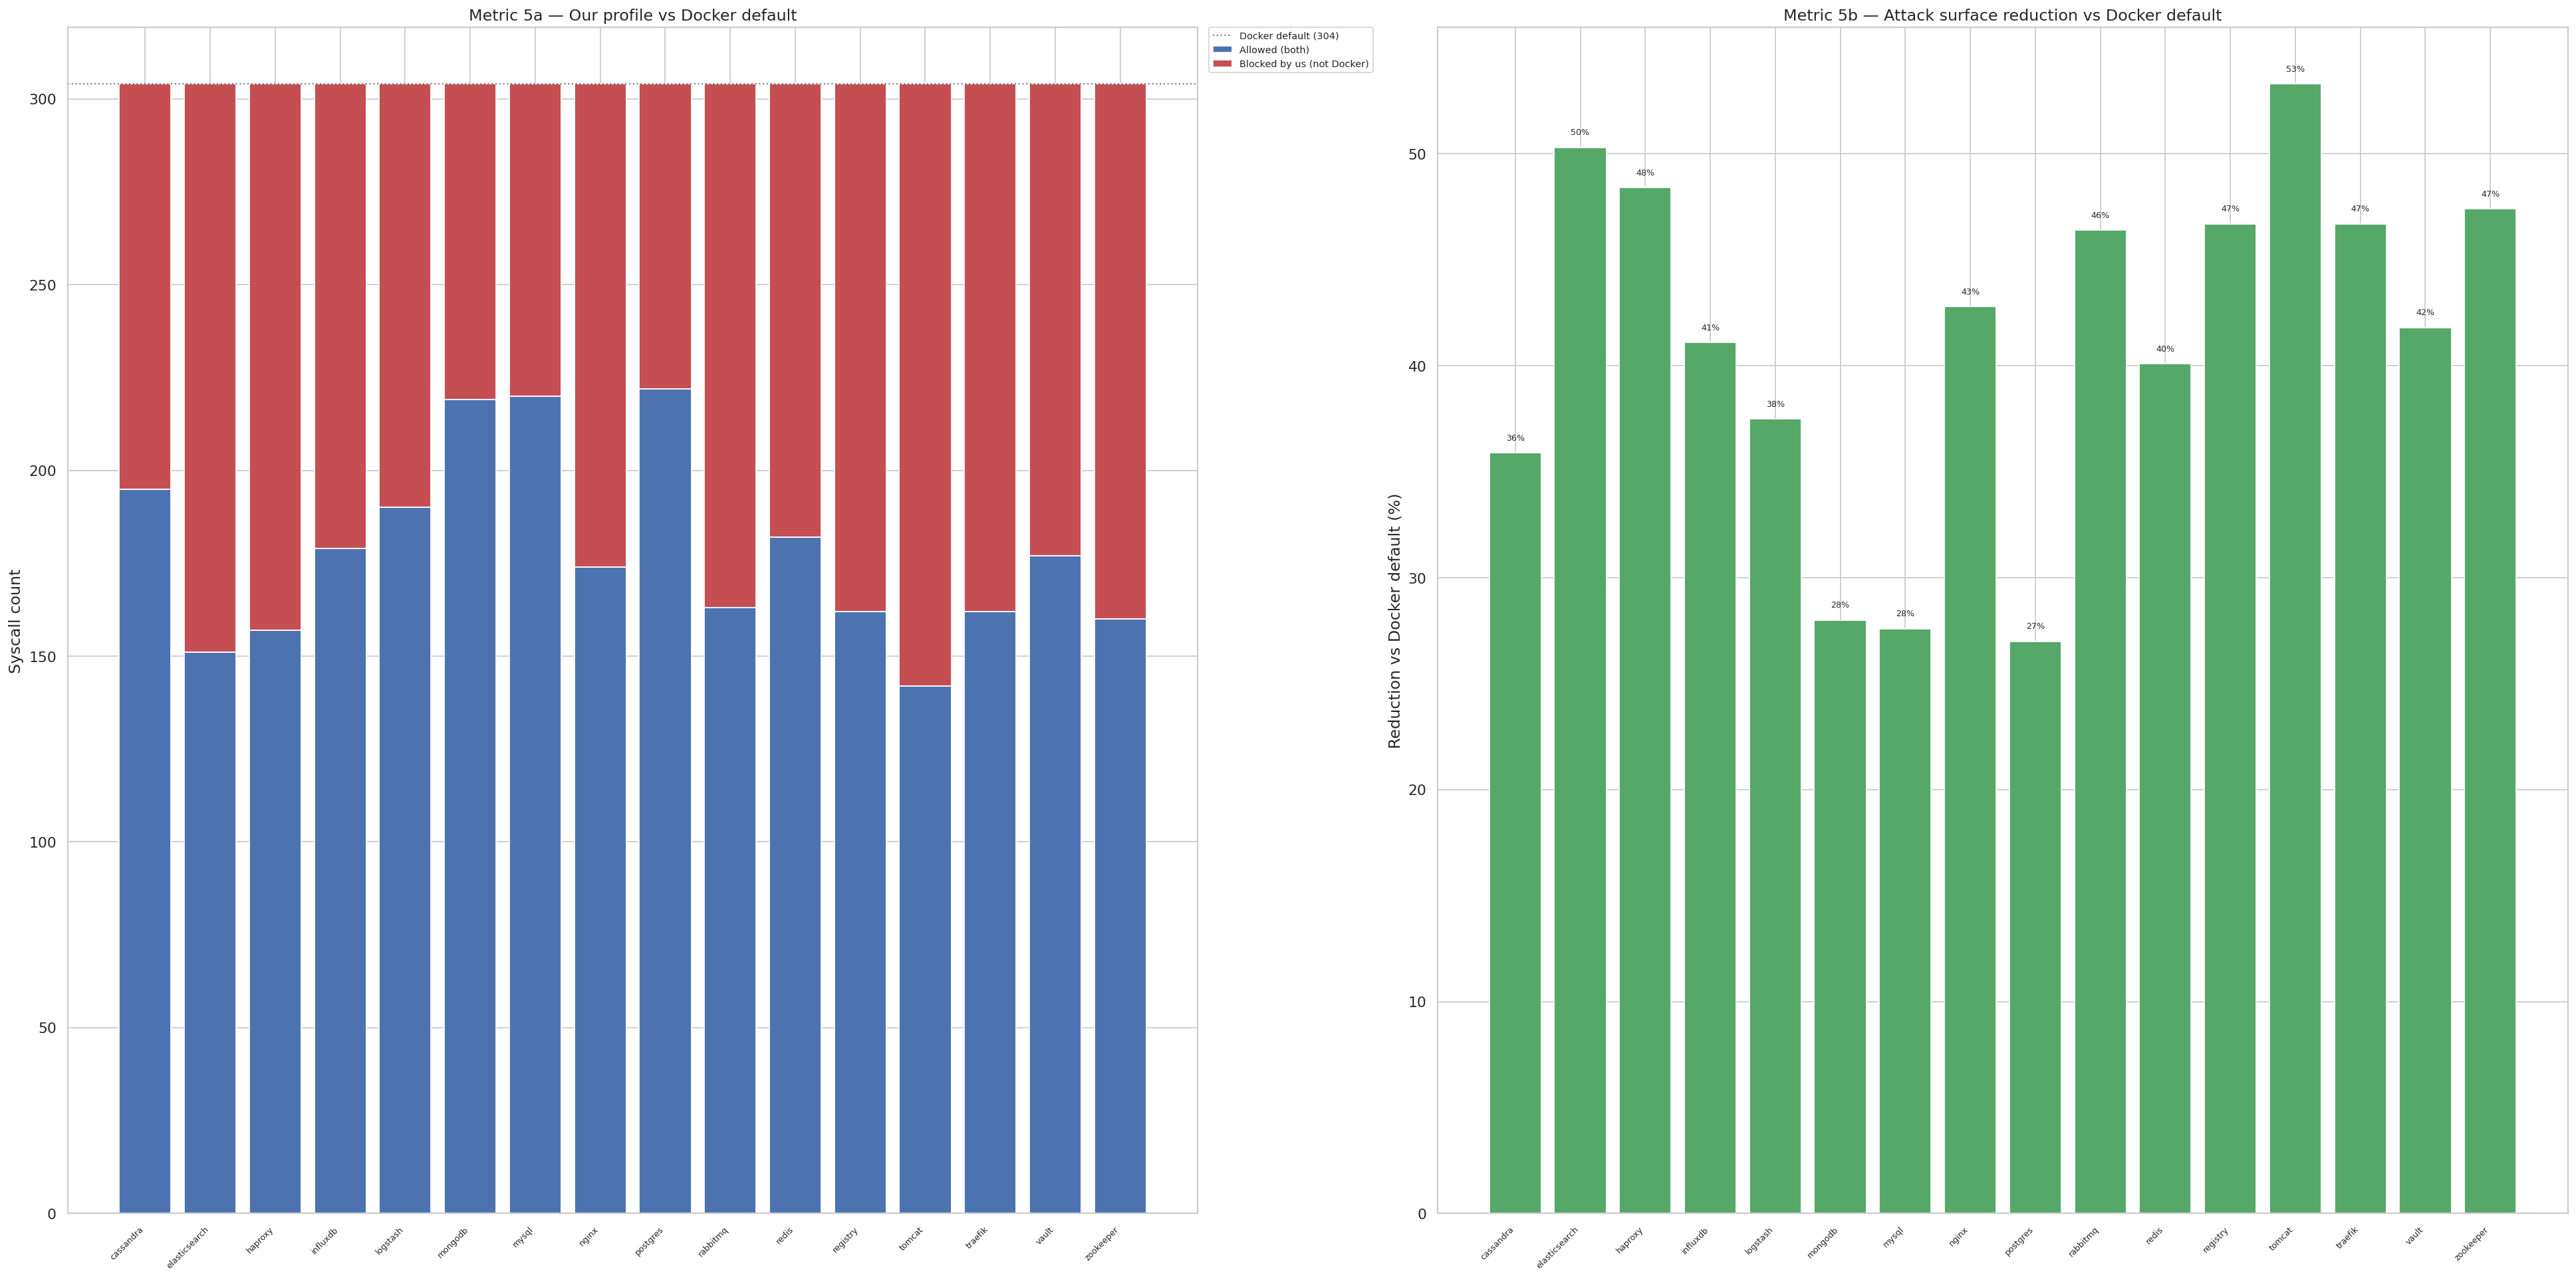

Docker default: 304 allowed syscalls
Average reduction: 41.3%
Best reduction: 53.3% (tomcat)


In [ ]:
df_plot = df_docker.copy()
df_plot['label'] = df_plot['image']
df_plot = df_plot.sort_values('label').reset_index(drop=True)
x = np.arange(len(df_plot))

fig, axes = plt.subplots(1, 2, figsize=(30, 15))

# Left: stacked bar
ax = axes[0]
ax.bar(x, df_plot['both_allowed'], color='#4C72B0', label='Allowed (both)')
ax.bar(x, df_plot['additionally_blocked'], bottom=df_plot['both_allowed'],
       color='#C44E52', label='Blocked with Constant-in')
ax.axhline(len(docker_allowed), color='grey', linestyle=':', linewidth=1.2,
           label=f'Docker default ({len(docker_allowed)})')
ax.set_xticks(x)
ax.set_xticklabels(df_plot['label'], fontsize=7, rotation=45, ha='right')
ax.set_ylabel('Syscall count')
ax.set_title('Metric 5a — Our profile vs Docker default')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0, fontsize=8)

# Right: reduction %
ax = axes[1]
colors = ['#55A868' if v >= 20 else '#DD8452' for v in df_plot['reduction_pct']]
bars = ax.bar(x, df_plot['reduction_pct'], color=colors)
for bar, val in zip(bars, df_plot['reduction_pct']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:.0f}%', ha='center', va='bottom', fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(df_plot['label'], fontsize=7, rotation=45, ha='right')
ax.set_ylabel('Reduction vs Docker default (%)')
ax.set_title('Metric 5b — Attack surface reduction vs Docker default')

plt.tight_layout()
save_plot('metric_5')
save_data(
    df_plot[['label', 'our_total', 'docker_total', 'both_allowed',
             'additionally_blocked', 'reduction_pct']].set_index('label'),
    'metric_5'
)
plt.show()

print(f'Docker default: {len(docker_allowed)} allowed syscalls')
print(f'Average reduction: {df_docker["reduction_pct"].mean():.1f}%')
best = df_docker.loc[df_docker['reduction_pct'].idxmax()]
print(f'Best reduction: {best["reduction_pct"]}% ({best["image"]})')


In [124]:
all_blocked = None
for allowed in merged.values():
    diff = docker_allowed - (allowed & ALL_SYSCALLS)
    all_blocked = diff if all_blocked is None else all_blocked & diff

print(f'Syscalls blocked by EVERY one of our {len(merged)} profiles (Docker still allows them on x86_64):')
print(f'  Count: {len(all_blocked)}')
print(f'  Names: {sorted(all_blocked)}')


Syscalls blocked by EVERY one of our 23 profiles (Docker still allows them on x86_64):
  Count: 37
  Names: ['cachestat', 'epoll_ctl_old', 'epoll_wait_old', 'eventfd', 'futex_requeue', 'futex_wait', 'futex_waitv', 'futex_wake', 'get_robust_list', 'get_thread_area', 'io_pgetevents', 'ioprio_get', 'ioprio_set', 'map_shadow_stack', 'membarrier', 'memfd_secret', 'modify_ldt', 'mq_getsetattr', 'mq_notify', 'mq_open', 'mq_timedreceive', 'mq_timedsend', 'mq_unlink', 'mseal', 'openat2', 'process_mrelease', 'process_vm_readv', 'remap_file_pages', 'restart_syscall', 'rt_tgsigqueueinfo', 'sched_getattr', 'sched_rr_get_interval', 'sched_setattr', 'set_thread_area', 'signalfd', 'timer_getoverrun', 'timerfd_gettime']


,image,confine_blocked,our_blocked,both_blocked,only_confine_blocked,only_our_blocked,delta_our_minus_confine,our_vs_confine_pct
0,cassandra,149,158,102,47,56,9,106.0
1,elasticsearch,154,217,127,27,90,63,140.9
2,influxdb,191,186,129,62,57,-5,97.4
3,logstash,184,175,117,67,58,-9,95.1
4,mysql,144,144,90,54,54,0,100.0
5,nginx,171,193,135,36,58,22,112.9
6,postgres,136,125,81,55,44,-11,91.9
7,rabbitmq,149,202,125,24,77,53,135.6
8,redis,174,184,131,43,53,10,105.7
9,registry,157,200,137,20,63,43,127.4


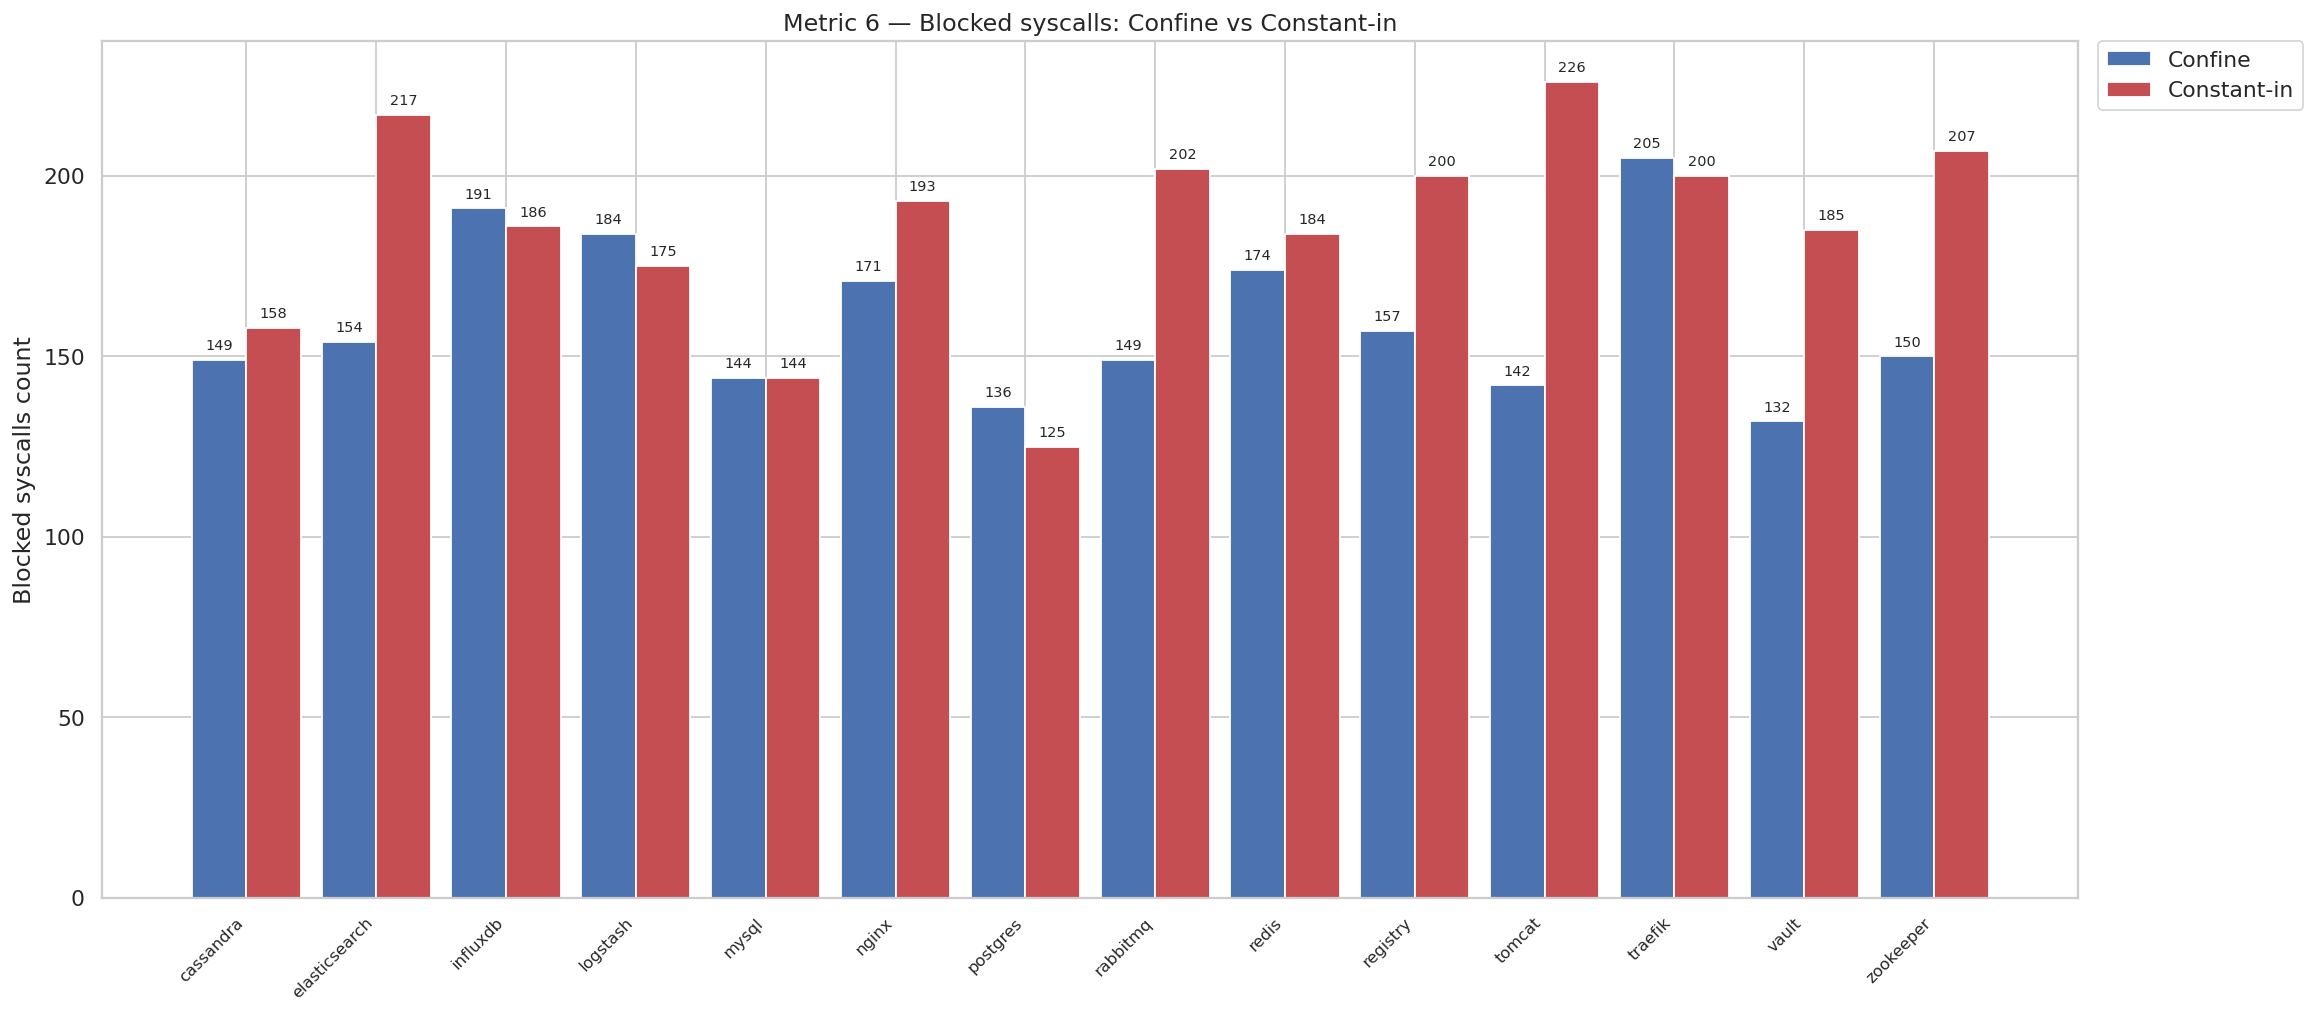

Overlapping profiles: 14
Average Confine blocked syscalls: 159.9
Average constant-in blocked syscalls: 185.9


In [ ]:
confine_blocked = {}
for f in sorted(CONFINE_RESULTS.glob('*.seccomp.json')):
    image = f.name.removesuffix('.seccomp.json')
    _, blocked = load_seccomp_policy(f)
    confine_blocked[image] = blocked

confine_rows = []
for (image, mode), allowed in sorted(metrics_profiles.items()):
    if image not in confine_blocked:
        continue
    our_blocked = ALL_SYSCALLS - (allowed & ALL_SYSCALLS)
    blocked_by_confine = confine_blocked[image]
    confine_rows.append({
        'image': image,
        'confine_blocked': len(blocked_by_confine),
        'our_blocked': len(our_blocked),
        'both_blocked': len(our_blocked & blocked_by_confine),
        'only_confine_blocked': len(blocked_by_confine - our_blocked),
        'only_our_blocked': len(our_blocked - blocked_by_confine),
        'delta_our_minus_confine': len(our_blocked) - len(blocked_by_confine),
        'our_vs_confine_pct': round(100 * len(our_blocked) / len(blocked_by_confine), 1) if blocked_by_confine else np.nan,
    })

df_confine_compare = pd.DataFrame(confine_rows).sort_values(['image']).reset_index(drop=True)
display(df_confine_compare[[
    'image', 'confine_blocked', 'our_blocked', 'both_blocked',
    'only_confine_blocked', 'only_our_blocked',
    'delta_our_minus_confine', 'our_vs_confine_pct'
]])

if df_confine_compare.empty:
    print('No overlapping images between our selected profiles and Confine sample.results')
else:
    df_plot = df_confine_compare.copy()
    df_plot['label'] = df_plot['image']
    x = np.arange(len(df_plot))
    width = 0.42

    fig, ax = plt.subplots(figsize=(18, 8))
    bars_confine = ax.bar(x - width / 2, df_plot['confine_blocked'], width,
                          color='#4C72B0', label='Confine')
    bars_ours = ax.bar(x + width / 2, df_plot['our_blocked'], width,
                       color='#C44E52', label='Constant-in')

    for bars in (bars_confine, bars_ours):
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                    f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(df_plot['label'], fontsize=9, rotation=45, ha='right')
    ax.set_ylabel('Blocked syscalls count')
    ax.set_title('Metric 6 — Blocked syscalls: Confine vs Constant-in')
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)

    plt.tight_layout()
    save_plot('metric_6')
    save_data(
        df_confine_compare[[
            'image', 'confine_blocked', 'our_blocked', 'both_blocked',
            'only_confine_blocked', 'only_our_blocked',
            'delta_our_minus_confine', 'our_vs_confine_pct'
        ]].set_index('image'),
        'metric_6'
    )
    plt.show()

    print(f'Overlapping profiles: {len(df_confine_compare)}')
    print(f'Average Confine blocked syscalls: {df_confine_compare["confine_blocked"].mean():.1f}')
    print(f'Average constant-in blocked syscalls: {df_confine_compare["our_blocked"].mean():.1f}')


In [126]:
summary_rows = []
for (image, mode), allowed in sorted(merged.items()):
    per_tool_data = next(
        (r['per_tool'] for r in all_records if r['image'] == image and r['mode'] == mode), {}
    )
    static_set  = set().union(*(per_tool_data.get(t, set())
                                for t in ['confine', 'syspart', 'sysfilter','go2seccomp']))
    dynamic_set = per_tool_data.get('tracee', set())
    add_blocked = docker_allowed - allowed
    summary_rows.append({
        'Image':              image,
        'Mode':               mode,
        'Merged syscalls':    len(allowed),
        'Static found':       len(static_set),
        'Dynamic found':      len(dynamic_set),
        'Mitigated CVEs':     len(mitigated_cves(allowed)),
        'Extra blocks':       len(add_blocked),
        'Reduction vs Docker':f"{round(100 * len(add_blocked) / len(docker_allowed), 1)}%",
    })

display(pd.DataFrame(summary_rows).sort_values(['Image','Mode']).reset_index(drop=True))

,Image,Mode,Merged syscalls,Static found,Dynamic found,Mitigated CVEs,Extra blocks,Reduction vs Docker
0,cassandra,static,217,208,110,15,109,35.9%
1,elasticsearch,static,158,135,86,47,153,50.3%
2,haproxy,bench,165,158,64,43,147,48.4%
3,haproxy,idle,165,158,62,43,147,48.4%
4,influxdb,static,189,179,93,34,125,41.1%
5,logstash,static,200,186,79,40,114,37.5%
6,mongodb,bench,242,238,97,21,85,28.0%
7,mongodb,idle,242,238,90,21,85,28.0%
8,mysql,bench,231,228,106,33,84,27.6%
9,mysql,idle,231,228,105,33,84,27.6%
